# MODEL D- OBJECTIVE 4: Graph Neural Network. 

In [5]:
# 'os' provides a portable way of using operating system dependent functionality like checking directories
import os

# 'platform' accesses underlying platform data such as OS name, release version, and hardware details
import platform

# 'sys' interacts strongly with the Python interpreter, exposing system paths and active executable locations
import sys

# ==========================================
# 1. PLATFORM & OPERATING SYSTEM INFORMATION
# ==========================================
# Access underlying system and hardware platform details
print("--- OS & Platform Details For Model D ---")
# Generic OS name (e.g., 'Linux', 'Windows', 'Darwin' for macOS)
print(f"OS Name: {platform.system()}")
# Specific release version (e.g., '5.15.0-101-generic', '10', '11')
print(f"OS Release: {platform.release()}")
# Detailed system build version information
print(f"OS Version: {platform.version()}")
# Combined string containing all available system and hardware details
print(f"Platform Detail: {platform.platform()}")


# ==========================================
# 2. ENVIRONMENT PATHS & EXECUTABLES
# ==========================================
# Track down the current execution context and active environments
print("\n--- Environment Paths For Model D ---")
# Current working directory inside the execution environment
print(f"Current Working Directory: {os.getcwd()}")
# Exact Python executable path currently running this Jupyter kernel
print(f"Active Python Executable: {sys.executable}")


# ==========================================
# 3. LINUX ENVIRONMENT DISTRIBUTION DETAILS
# ==========================================
# Read the native Linux configuration file if running inside an OS like Ubuntu
print("\n--- OS Distribution Details For Model D ---")
try:
    with open("/etc/os-release", "r") as f:
        for line in f:
            if line.startswith(("NAME=", "VERSION=")):
                print(line.strip())
except FileNotFoundError:
    print("Notice: /etc/os-release not found. (This occurs if running natively on Windows instead of WSL/Linux).")

--- OS & Platform Details For Model D ---
OS Name: Linux
OS Release: 6.6.114.1-microsoft-standard-WSL2
OS Version: #1 SMP PREEMPT_DYNAMIC Mon Dec  1 20:46:23 UTC 2025
Platform Detail: Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.35

--- Environment Paths For Model D ---
Current Working Directory: /home/unbukenny/SHARC
Active Python Executable: /home/unbukenny/miniconda3/envs/SHARC/bin/python

--- OS Distribution Details For Model D ---
NAME="Ubuntu"
VERSION="22.04.5 LTS (Jammy Jellyfish)"


In [ ]:
### 1. Install Dependencies (run once),Imports and Basic Setup.

In [1]:
# This cell installs the required PyTorch Geometric packages and their
# dependencies for CPU‑based Torch 2.0.0. Run it only when setting up the
# environment; on subsequent runs it will simply confirm the packages exist.

import subprocess, sys

def pip_install(*pkgs):
    """
    Helper to run 'pip install' from the current Python interpreter.
    Uses --quiet to reduce output.
    """
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *pkgs])

# Install the main torch_geometric package
pip_install("torch_geometric")

print("Dependencies installed.")

Dependencies installed.


In [1]:
import torch
import torch_geometric

print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch Geometric version: {torch_geometric.__version__}")

C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


PyTorch version: 2.11.0+cpu
PyTorch Geometric version: 2.7.0


In [2]:
# Install CPU-only PyTorch, torchvision, and torchaudio from the official pytorch channel
# %pip install torch torchvision torchaudio

# Install the pyannote.audio library (required for speaker diarization metrics)
# %pip install pyannote.audio
# %pip install --force-reinstall pyannote.audio

# Update/Reinstall numpy
# %pip install --upgrade --force-reinstall numpy
# %pip install "numpy<2.0"
# Install audio processing libraries (librosa, soundfile) and SpeechBrain for speech tasks
# !pip install librosa soundfile speechbrain

In [10]:
import sys
print(sys.version)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [7]:
import sys
print(sys.executable)

C:\Users\HP\anaconda3\python.exe


In [3]:
# --- Standard library ---
import os, json, warnings, itertools         # os: system operations; json: serialization; warnings: filter warnings; itertools: efficient looping

# Import the sys module to access system-specific parameters and functions
import sys

# Import the librosa module for audio and music analysis
import librosa

# Print the installed version of librosa to confirm successful installation
print(librosa.__version__)

# --- Scientific computing ---
import numpy as np                           # Numerical arrays and operations
import pandas as pd                          # DataFrames and tabular data handling

# --- Plotting ---
import matplotlib.pyplot as plt              # Core plotting interface
import matplotlib.patches as mpatches        # Custom patch objects (e.g., legend handles)
import seaborn as sns                        # Statistical data visualisation

# --- Path and data structures ---
from pathlib import Path                     # Object-oriented filesystem paths
from collections import defaultdict, Counter # defaultdict: auto-initialised dict; Counter: frequency counting
from copy import deepcopy                    # Deep copy of nested objects

# --- Deep learning framework ---
import torch                                 # PyTorch main module
import torch.nn as nn                        # Neural network layers and loss functions
import torch.nn.functional as F              # Functional API (activation functions, etc.)
from torch.utils.data import Dataset, DataLoader  # Custom dataset and mini-batch loading

# --- Graph neural networks (PyG) ---
from torch_geometric.data import Data        # Graph data container (nodes, edges, features)
from torch_geometric.nn import SAGEConv, GCNConv  # GraphSAGE and GCN convolution layers

# --- Scikit-learn ---
from sklearn.metrics import silhouette_score, f1_score   # Clustering quality and classification metric
from sklearn.cluster import AgglomerativeClustering      # Hierarchical clustering
from sklearn.manifold import TSNE                        # t-SNE for dimensionality reduction

# --- SciPy ---
from scipy.spatial.distance import cosine as cosine_dist # Cosine distance (1 - cosine similarity)
from scipy.ndimage import median_filter                  # Median filter for smoothing

# --- Pyannote (speaker diarization) ---
from pyannote.core import Annotation, Segment            # Annotation timeline and time segments
from pyannote.metrics.diarization import DiarizationErrorRate # DER evaluation metric


# --- Environment setup ---
warnings.filterwarnings("ignore")            # Suppress warning messages

SEED = 42                                    # Reproducibility seed
torch.manual_seed(SEED)                      # Seed for PyTorch CPU operations
np.random.seed(SEED)                         # Seed for NumPy
DEVICE = torch.device("cpu")                 # Explicitly use CPU
torch.set_num_threads(os.cpu_count())        # Utilise all available CPU cores


print("PyTorch", torch.__version__, "| Device", DEVICE)  # Confirm versions and device
print(sys.version)           # full version string
print(sys.version_info)      # tuple (major, minor, micro, releaselevel, serial)
print("Imports successful")  # Confirm that all imports were successful

0.11.0


C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


PyTorch 2.11.0+cpu | Device cpu
3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
sys.version_info(major=3, minor=12, micro=7, releaselevel='final', serial=0)
Imports successful


### Step 2 - Global Configuration.

In [5]:
# Cell 3 – Configuration
BASE_PATH = Path.cwd()                      # Set BASE_PATH to the current working directory

TIER_CONFIG = {                             # Dictionary mapping noise tiers to their audio directory and file prefix
    "Very_Clean": {"audio_dir": BASE_PATH / "Free_MultiSpeaker_Audios",  "file_prefix": "Session_"},  # Clean audio tier: directory and prefix
    "Pink_Noise": {"audio_dir": BASE_PATH / "Pink_Noise_MultiSpeaker_Audios", "file_prefix": "Noisy_Session_"},  # Pink noise tier: directory and prefix
    "ER_Noise":   {"audio_dir": BASE_PATH / "Very_Noisy_MultiSpeaker_Audios", "file_prefix": "ER_Noisy_Session_"},  # Extreme reverberant noise tier: directory and prefix
}

GT_CSV  = BASE_PATH / "ground_truth_data.csv"     # Primary path to the ground truth CSV file
GT_RTTM = BASE_PATH / "ground_truth.rttm"         # Path to the ground truth RTTM file
if not GT_CSV.exists():                            # If the primary CSV file does not exist,
    GT_CSV = BASE_PATH / "combined_ground_truth_timestamps.csv"  # use the alternative combined timestamps file

OUTPUT_ROOT = BASE_PATH / "Objective4_ESHARC_Outputs_V5"  # Root directory for all output files
OUTPUT_ROOT.mkdir(exist_ok=True)                        # Create the output directory if it doesn't already exist

EMBEDDING_DIM = 192       # Dimensionality of speaker embeddings
N_SPEAKERS = 4            # Total number of speakers in the dataset
FRAME_STEP  = 0.01        # Step size between consecutive frames in seconds (10 ms)


CFG = {                                           # Main configuration dictionary for the GNN model and training
    # Graph
    "k_neighbors": 60,                            # Number of nearest neighbors used to build the affinity graph
    "affinity_thresh": 0.2,                       # Cosine similarity threshold for creating graph edges
    # R‑GNN
    "r_hidden": 256,                              # Hidden dimension size in the relation GNN
    "r_layers": 3,                                # Number of message-passing layers in the relation GNN
    "r_dropout": 0.3,                             # Dropout probability in the relation GNN
    # C‑GNN (not used for clustering, only for representation learning)
    "c_hidden": 128,                              # Hidden dimension size in the clustering GNN (C-GNN)
    "c_layers": 2,                                # Number of layers in the c-GNN
    "c_dropout": 0.3,                             # Dropout probability in the c-GNN
    # Training
    "lr": 1e-3,                                   # base learning rate for Adam
    "weight_decay": 1e-3,                         # Weight decay (L2 regularization) coefficient
    "epochs": 2000,                               # Maximum number of training epochs
    "batch_size": 4,                              # Number of samples per training batch
    "repr_weight": 1.5,                           # loss weight for contrastive (representation) term
    "cls_weight": 0.0,                            # Loss weight for edge classification (disabled, set to 0.0)
    "aux_weight": 1.0,                            # Loss weight for auxiliary speaker classification
    "noise_aug_std": 0.01,                        # Standard deviation of noise added for data augmentation (scaling)
    "margin": 0.2,                                # Margin value used in the triplet loss
    # Early stopping
    "patience": 200,                              # Number of epochs to wait for improvement before stopping early
}
print("Configuration loaded.")                    # Print confirmation that configuration has been successfully loaded

Configuration loaded.


### Step 3 - ECAPA-TDNN Embedding Extractor.

In [5]:
import librosa                                          # Import librosa for audio processing and loading
import subprocess                                       # Import subprocess to run external system commands and processes
import sys                                              # Import sys to interact with the Python runtime environment 
from pathlib import Path                                # Import Path from pathlib for object-oriented file and directory path manipulation

# Global cache for the ECAPA-TDNN model (singleton pattern to avoid reloading)
_ECAPA_MODEL = None

def _get_ecapa():
    global _ECAPA_MODEL

    # Load the model only once (lazy initialization)
    if _ECAPA_MODEL is None:
        # Attempt to import SpeechBrain's speaker recognition module
        try:
            from speechbrain.inference.speaker import EncoderClassifier
        except ModuleNotFoundError:
            # If SpeechBrain is missing, install it automatically
            print("speechbrain not found. Installing via pip...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "speechbrain"])
            from speechbrain.inference.speaker import EncoderClassifier  # retry import

        # Define cache directory for the pretrained model
        cache = Path.home() / ".cache" / "speechbrain" / "spkrec-ecapa-voxceleb"

        # Load the ECAPA-TDNN model pretrained on VoxCeleb
        _ECAPA_MODEL = EncoderClassifier.from_hparams(
            source="speechbrain/spkrec-ecapa-voxceleb",
            savedir=str(cache),
            run_opts={"device": str(DEVICE)}   # requires DEVICE variable to be set
        )

    return _ECAPA_MODEL

def extract_window_embeddings(audio_path, win_sec=1.5, hop_sec=0.75, sr_out=16000):
    if not os.path.exists(audio_path):                  # Handle missing audio file 
        return np.zeros((0, EMBEDDING_DIM)), []         # Return empty arrays if file does not exist
        
    audio, sr = librosa.load(audio_path, sr=sr_out, mono=True)  # Load audio, resample to sr_out, convert to mono
    win_samples = int(win_sec * sr)                     # Window size in samples
    hop_samples = int(hop_sec * sr)                     # Hop (step) size in samples
    model = _get_ecapa()                                # Obtain the ECAPA model (lazy loading)
    emb_list, time_list = [], []                        # Lists to store embeddings and their time intervals
    
    for start in range(0, len(audio)-win_samples+1, hop_samples):  # Iterate over sliding windows
        chunk = audio[start:start+win_samples]          # Extract current window of audio samples
        
        with torch.no_grad():                           # Disable gradient computation for inference
            sig = torch.FloatTensor(chunk).unsqueeze(0).to(DEVICE)  # Convert window to tensor, add batch dim, move to device
            emb = model.encode_batch(sig).squeeze().cpu().numpy()  # Compute embedding, remove batch dim, bring to CPU as numpy array
        norm = np.linalg.norm(emb)                      # Compute L2 norm of the embedding vector
        emb = emb / max(norm, 1e-6)                     # Normalise embedding, avoid division by zero
        emb_list.append(emb)                            # Append normalised embedding to list
        time_list.append([start/sr, (start+win_samples)/sr])  # Record start and end time of window in seconds
        
    if emb_list:                                        # If at least one embedding was generated
        return np.vstack(emb_list), time_list           # Stack embeddings into a 2D array and return with time intervals
    return np.zeros((0, EMBEDDING_DIM)), []             # Otherwise return empty arrays
    
print("Embedding extractor ready.")                     # Inform that the module is loaded

Embedding extractor ready.


### Step 4 — Ground-Truth Speaker Label Alignment.

In [6]:
# Load ground-truth segmentation from a CSV file.
def load_ground_truth(csv_path):
    
    # Read the CSV into a DataFrame.
    df = pd.read_csv(csv_path)
    # Strip whitespace from column names to avoid leading/trailing spaces.
    df.columns = [c.strip() for c in df.columns]
    # If the CSV does not already contain precise Start_Seconds,
    # synthetic timing from the text and speaker turns need to be created .
    if "Start_Seconds" not in df.columns:
        rows = []
        # Process each session separately to maintain chronological order.
        for sid, grp in df.groupby("Session_ID"):
            t = 0.0  # start time accumulator for the session
            # Iterate over turns in order (they appear in the CSV).
            for _, r in grp.iterrows():
                # Estimate word count from the "Text" field (default to empty string).
                wc = len(str(r.get("Text", "")).split())
                # Heuristic: each word takes ~0.4 seconds, but enforce minimum 3 seconds.
                dur = max(3.0, wc * 0.4)
                # Append a row with calculated start and end times (rounded to milliseconds).
                rows.append({"Session_ID": sid,
                             "Speaker": r["Speaker"],
                             "Start_Seconds": round(t, 3),
                             "End_Seconds": round(t + dur, 3)})
                # Advance time by turn duration plus a 0.25 s gap.
                t += dur + 0.25
        # Build a new DataFrame from the generated rows.
        df = pd.DataFrame(rows)
    # Ensure data types are correct.
    df["Session_ID"] = df["Session_ID"].astype(int)
    df["Start_Seconds"] = df["Start_Seconds"].astype(float)
    df["End_Seconds"] = df["End_Seconds"].astype(float)
    return df

# Identify which speaker dominates a given time interval in the ground truth.
def get_dominant_speaker(gt_df, session_id, start, end):
    # Filter ground truth to the desired session.
    sub = gt_df[gt_df["Session_ID"] == session_id]
    # Calculate overlap length for each turn with [start, end].
    # Overlap = min(end, turn_end) - max(start, turn_start), clamped to zero.
    ov = np.maximum(0,
                    np.minimum(sub["End_Seconds"].values, end) -
                    np.maximum(sub["Start_Seconds"].values, start))
    # If no overlap exceeds a tiny threshold, no speaker can be assigned.
    if ov.max() < 1e-3:
        return None
    # Return the speaker of the turn with the largest overlap.
    return sub.iloc[ov.argmax()]["Speaker"]

# Convert a list of detected segments (embeddings + time stamps) into integer speaker labels
# using the ground-truth alignment.
def assign_speaker_labels(emb_list, time_list, gt_df, session_id):
    # For each time interval, find the dominant ground-truth speaker.
    speakers = [get_dominant_speaker(gt_df, session_id, s, e) for s, e in time_list]
    # Collect all unique speaker names (excluding None).
    unique = sorted({x for x in speakers if x is not None})
    # Map each unique speaker to a consecutive integer label.
    s2i = {s: i for i, s in enumerate(unique)}
    # Build integer label array; any interval without a dominant speaker gets -1.
    return np.array([s2i.get(sp, -1) for sp in speakers], dtype=int)

# Load the ground-truth CSV into a global DataFrame for later use.
GT_DF = load_ground_truth(str(GT_CSV))
print("Ground truth loaded:", len(GT_DF), "turns")

Ground truth loaded: 105 turns


#### Step 5 – Speaker Graph Construction.

In [7]:
def build_speaker_graph(embeddings, labels, k=CFG["k_neighbors"], thresh=CFG["affinity_thresh"]):
    # Build a PyTorch Geometric graph from a set of speaker embeddings.
    # Edges are created using a k‑nearest neighbour strategy with a similarity threshold.
    N = len(embeddings)
    if N < 2:
        # Single‑node special case: return a graph with one node, a dummy self‑loop and label -1.
        return Data(x=torch.zeros(1,EMBEDDING_DIM),
                    edge_index=torch.zeros(2,1,dtype=torch.long),
                    edge_attr=torch.zeros(1), y=torch.full((1,),-1,dtype=torch.long))

    # Convert embeddings to a float tensor (used as node features)
    emb_t = torch.FloatTensor(embeddings)

    # Compute pairwise similarity matrix (dot product, assuming normalised embeddings)
    sim_mat = emb_t @ emb_t.T

    src, dst, ws = [], [], []           # edge sources, destinations and weights
    for i in range(N):
        row = sim_mat[i].clone()        # similarities of node i to all others
        row[i] = -1.0                   # exclude self from the top‑k selection
        # Get indices of the k most similar other nodes (k = min(k, N-1) to avoid error)
        top_k = torch.topk(row, min(k, N-1)).indices.tolist()
        for j in top_k:
            s_val = float(sim_mat[i,j])
            if s_val >= thresh:         # only keep edges above the affinity threshold
                src.append(i); dst.append(j); ws.append(s_val)

    # Fallback: if no edge passes the threshold, chain nodes sequentially
    if not src:
        src, dst = list(range(N-1)), list(range(1,N))
        ws = [float(sim_mat[i,i+1]) for i in range(N-1)]

    # Create PyG tensors
    edge_index = torch.tensor([src,dst], dtype=torch.long)   # shape [2, E]
    edge_attr  = torch.tensor(ws, dtype=torch.float32)       # edge weights
    y = torch.tensor(labels, dtype=torch.long)               # node labels

    # Return a complete Data object
    return Data(x=emb_t, edge_index=edge_index, edge_attr=edge_attr, y=y)


def graphs_from_tier(tier_name, gt_df, n_sessions=10):
    # Build graphs for all sessions belonging to a single dataset tier.
    # Uses configuration from TIER_CONFIG (audio directory, file prefix, etc.)
    cfg = TIER_CONFIG[tier_name]
    audio_dir = cfg["audio_dir"]
    prefix = cfg["file_prefix"]
    results = []
    import re

    # Try to detect the actual file prefix from existing .wav files.
    # This handles cases where the prefix in the config doesn't match the files exactly.
    wav_files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]
    detected = set(re.match(r'^(.*?)(\d+)\.wav$', f).group(1)
                   for f in wav_files if re.match(r'^(.*?\d+)\.wav$', f))
    if detected and prefix not in detected:
        prefix = sorted(detected)[0]   # fall back to the first detected prefix

    # Process each session ID from 1 to n_sessions
    for sid in range(1, n_sessions+1):
        # Look for the session audio file using several possible naming patterns
        candidates = [audio_dir / f"{prefix}{sid}.wav",
                      audio_dir / f"{prefix}{sid:02d}.wav",
                      audio_dir / f"{prefix}{sid:03d}.wav"]
        audio_path = next((p for p in candidates if p.exists()), None)
        if audio_path is None: continue          # skip if no file found

        # Extract windowed embeddings and their time stamps from the audio
        embs, times = extract_window_embeddings(str(audio_path))
        if embs.shape[0] < 3: continue           # need at least 3 windows to build a meaningful graph

        # Assign ground‑truth speaker labels to each embedding window
        labels = assign_speaker_labels(embs, times, gt_df, sid)

        # Build the speaker graph from embeddings and labels
        graph = build_speaker_graph(embs, labels)

        # Attach metadata to the graph object
        graph.session_id = sid
        graph.tier = tier_name
        graph.times = times
        results.append((sid, graph))

    return results


# Main loop: build graphs for every tier in the configuration
TIER_GRAPHS = {}
for tier in TIER_CONFIG:
    TIER_GRAPHS[tier] = graphs_from_tier(tier, GT_DF)
    print(tier, ":", len(TIER_GRAPHS[tier]), "sessions")

Very_Clean : 10 sessions
Pink_Noise : 10 sessions
ER_Noise : 10 sessions


### Step 6 – Representation GNN/R-GNN (GraphSAGE).

In [8]:
class RGNN(nn.Module):
    """
    Relational Graph Neural Network based on GraphSAGE convolutions.
    Uses residual connections, layer normalization, and dropout.
    """
    def __init__(self, input_dim=EMBEDDING_DIM, hidden_dim=CFG["r_hidden"],
                 n_layers=CFG["r_layers"], dropout=CFG["r_dropout"]):
        super().__init__()
        self.dropout = dropout

        # Linear projection of input features into the hidden dimension
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # Multiple GraphSAGE convolution layers with corresponding LayerNorm
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(n_layers):
            self.layers.append(SAGEConv(hidden_dim, hidden_dim))
            self.norms.append(nn.LayerNorm(hidden_dim))

    def forward(self, x, edge_index):
        """
        x: Node features [num_nodes, input_dim]
        edge_index: Graph connectivity [2, num_edges]
        Returns: Node embeddings [num_nodes, hidden_dim]
        """
        # Initial projection to hidden size
        h = self.input_proj(x)

        # Apply each SAGE layer with skip connection, normalization, and dropout
        for layer, norm in zip(self.layers, self.norms):
            h_new = layer(h, edge_index)       # GraphSAGE neighborhood aggregation
            h_new = norm(h_new)                # Layer normalization
            h_new = F.dropout(h_new, p=self.dropout, training=self.training)
            h = h + h_new                      # Residual connection

        return h

### Step 7 — Clustering GNN (C-GNN).

In [9]:
class CGNN(nn.Module):
    def __init__(self, input_dim=CFG["r_hidden"], hidden_dim=CFG["c_hidden"],
                 n_layers=CFG["c_layers"], dropout=CFG["c_dropout"]):
        super().__init__()                                                      # Initialize the parent nn.Module class
        self.dropout = dropout                                                  # Store dropout probability
        self.convs = nn.ModuleList()                                            # Will hold the GCN convolution layers
        self.norms = nn.ModuleList()                                            # Will hold the LayerNorm for each conv block
        in_dim = input_dim                                                      # Feature dimension entering the first block
        
        for _ in range(n_layers):                                               # Build n_layers conv‑norm blocks
            self.convs.append(GCNConv(in_dim, hidden_dim))                     # GCN convolution: in_dim → hidden_dim
            self.norms.append(nn.LayerNorm(hidden_dim))                        # Normalisation after the convolution
            in_dim = hidden_dim                                                 # Output of this block becomes input for the next
            
        # Multilayer Perceptron (MLP) that maps concatenated source‑target node features to a scalar edge score
        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim),                               # 2·hidden → hidden
            nn.ReLU(),                                                          # Non‑linearity
            nn.Dropout(dropout),                                                # Regularisation
            nn.Linear(hidden_dim, hidden_dim//2),                              # hidden → hidden//2
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, 1))                                        # hidden//2 → 1 (raw edge logit)

    def forward(self, h, edge_index, edge_attr=None):
        # Propagate node features through the GCN stack
        for conv, norm in zip(self.convs, self.norms):
            h = conv(h, edge_index, edge_weight=edge_attr)                      # Message‑passing convolution
            h = norm(h)                                                         # Layer normalisation
            h = F.relu(h)                                                       # ReLU activation
            h = F.dropout(h, p=self.dropout, training=self.training)           # Dropout (only active during training)
        src, dst = edge_index                                                  # Split edge_index into source and destination nodes
        pair = torch.cat([h[src], h[dst]], dim=-1)                             # Concatenate features of node pairs (per edge)
        return self.edge_mlp(pair).squeeze(-1)                                 # Compute edge scores, remove last dimension

### Step 8- E‑SHARC model with auxiliary speaker classifier.

In [10]:
class ESHARCModel(nn.Module):                          # Define the E‑SHARC model class (inherits from PyTorch module)
    def __init__(self, n_speakers=N_SPEAKERS):         # Constructor: default number of speakers from global constant
        super().__init__()                             # Initialize the parent nn.Module
        self.r_gnn = RGNN()                            # Relational graph network for node embeddings
        self.c_gnn = CGNN()                            # Cross‑graph network for edge scores
        self.speaker_head = nn.Linear(CFG["r_hidden"], n_speakers)   # auxiliary classifier (speaker ID from node embeddings)
    def forward(self, data):                           # Forward pass: data is a PyG Data object
        r_embs = self.r_gnn(data.x, data.edge_index)   # Extract relational node embeddings
        scores = self.c_gnn(r_embs, data.edge_index, data.edge_attr) # Compute edge-level scores (e.g., coreference affinity)
        spk_logits = self.speaker_head(r_embs)         # Speaker classification logits for each node (N, n_speakers)
        return scores, r_embs, spk_logits              # Return scores, embeddings, and speaker logits

def edge_labels_from_nodes(edge_index, node_labels):   # Utility to generate same-speaker labels per edge
    src, dst = edge_index                              # Source and destination indices of edges
    same = (node_labels[src] == node_labels[dst]).float()  # 1.0 if same speaker, 0.0 otherwise
    valid = (node_labels[src] >= 0) & (node_labels[dst] >= 0) # Mask: valid when both node speakers are known (non‑negative)
    return same, valid                                 # Return label tensor and validity mask

model = ESHARCModel().to(DEVICE)                       # Instantiate the model and move to configured device
optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])  # Adam optimizer with L2 regularization
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)  # LR scheduler: halve LR every 200 epochs
print("Model created. Parameters:", sum(p.numel() for p in model.parameters()))  # Display total number of trainable parameters

Model created. Parameters: 537093


### Step 9-Prepare train/val (multi‑tier).

In [11]:
# Create an empty list to hold all graphs combined from all tiers
all_graphs = []
# Iterate over each tier (dictionary key: tier name, value: list of graphs)
for tier_name, graphs in TIER_GRAPHS.items():
    # Extend the combined list with the graphs from the current tier
    all_graphs.extend(graphs)

# Shuffle the combined list randomly (in-place)
np.random.shuffle(all_graphs)
# Determine the split index for 80% training data
split = int(0.8 * len(all_graphs))
# Slice the shuffled list: first 80% become training graphs
train_graphs = all_graphs[:split]
# Remaining 20% become validation graphs
val_graphs   = all_graphs[split:]
# Print the sizes of the two sets for verification
print(f"Train: {len(train_graphs)} graphs, Val: {len(val_graphs)}")

Train: 24 graphs, Val: 6


### Step 10-Training loop with warmup.

In [12]:
CFG["warmup_epochs"] = 100                 # number of epochs for linear warm‑up

optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])  # Adam optimiser
# Cosine annealing scheduler will start after warmup
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"]-CFG["warmup_epochs"])  # scheduler that runs after warmup, cosine annealing over remaining epochs

def get_warmup_lr(epoch, base_lr, warmup_epochs):   # compute LR during warm‑up
    if epoch < warmup_epochs:                       # if still warming up
        return base_lr * (epoch + 1) / warmup_epochs # linear ramp from 0 to base_lr
    return None   # after warm‑up, return None so the scheduler takes over

def augment_features(graph, x, std=CFG["noise_aug_std"]):  # training‑time noise augmentation
    if not model.training or (hasattr(graph, 'tier') and graph.tier == "ER_Noise"):  # skip if evaluating or already noisy tier
        return x                                    # return unchanged features
    return x + torch.randn_like(x) * std         # add Gaussian noise

def train_epoch(epoch):                           # one full training epoch
    model.train()                                 # set model to training mode
    total_loss = 0.0                               # initialize cumulative loss
    indices = np.random.permutation(len(train_graphs))  # shuffle graph indices
    bs = CFG["batch_size"]                         # batch size
    num_batches = 0                                # counter for batches processed

    # Manual warmup LR
    lr = get_warmup_lr(epoch, CFG["lr"], CFG["warmup_epochs"])  # compute warmup learning rate
    if lr is not None:                             # if in warmup phase, override optimizer LR
        for param_group in optimizer.param_groups: # iterate over parameter groups
            param_group['lr'] = lr                 # set warmup learning rate

    for start in range(0, len(train_graphs), bs):  # loop over batches
        batch_idx = indices[start:start+bs]        # indices for current batch
        optimizer.zero_grad()                      # reset gradients

        all_embs, all_labs, spk_losses = [], [], []  # collect embeddings, labels, and speaker losses across the batch

        for idx in batch_idx:                      # iterate over graph indices in the batch
            _, graph = train_graphs[idx]           # unpack (id, graph) from training list
            data = deepcopy(graph).to(DEVICE)      # deep copy graph and move to device
            data.x = augment_features(graph, data.x)  # apply noise augmentation to node features

            scores, r_embs, spk_logits = model(data)  # forward pass: scores, embeddings, speaker logits

            vmask = data.y >= 0                   # only labelled nodes
            if vmask.sum() > 0:                    # if any labelled node
                aux_loss = F.cross_entropy(spk_logits[vmask], data.y[vmask])  # cross-entropy auxiliary loss
                spk_losses.append(aux_loss)        # collect auxiliary loss

            if vmask.sum() > 1:                    # if at least two labelled nodes for embeddings
                all_embs.append(r_embs[vmask])     # store embeddings of labelled nodes
                all_labs.append(data.y[vmask])     # store labels

        # Batch‑wide triplet contrastive loss
        if all_embs:                               # if any embeddings has been collected 
            all_embs = torch.cat(all_embs, dim=0)  # concatenate all batch embeddings
            all_labs = torch.cat(all_labs, dim=0)  # concatenate all labels
            n = all_embs.size(0)                   # number of samples
            if n >= 4:                             # need at least 4 samples for meaningful hardest mining
                embs_norm = F.normalize(all_embs, dim=1)  # L2-normalize embeddings
                sim = embs_norm @ embs_norm.T      # cosine similarity matrix
                dist = (1.0 - sim).clamp(min=0)    # cosine distance (clamped to >=0)
                same_mask = (all_labs.unsqueeze(0) == all_labs.unsqueeze(1)) & ~torch.eye(n, dtype=torch.bool, device=DEVICE)  # mask for same class pairs (excluding self)
                diff_mask = ~same_mask             # mask for different class pairs
                hardest_pos = dist[same_mask].max() if same_mask.any() else torch.tensor(0.0, device=DEVICE)  # hardest positive distance (max intra-class distance)
                hardest_neg = dist[diff_mask].min() if diff_mask.any() else torch.tensor(1.0, device=DEVICE)  # hardest negative distance (min inter-class distance)
                contrast_loss = F.relu(hardest_pos - hardest_neg + CFG["margin"])  # triplet hinge loss with margin
            else:                                  # not enough samples, loss zero
                contrast_loss = torch.tensor(0.0, device=DEVICE)  # zero contrastive loss
        else:                                      # no embeddings collected
            contrast_loss = torch.tensor(0.0, device=DEVICE)  # zero loss

        loss = CFG["repr_weight"] * contrast_loss  # weighted contrastive loss
        if spk_losses:                             # if auxiliary losses exist
            loss += CFG["aux_weight"] * torch.stack(spk_losses).mean()  # add mean auxiliary loss with weight

        loss.backward()                            # backpropagation
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)  # gradient clipping to prevent explosion
        optimizer.step()                           # update parameters

        total_loss += loss.item()                  # accumulate batch loss
        num_batches += 1                           # increment batch counter

    return total_loss / max(1, num_batches)         # average loss per batch over epoch

def compute_val_silhouette():                      # validation silhouette score
    model.eval()                                   # evaluation mode
    embs, labs = [], []                            # lists for embeddings and labels
    with torch.no_grad():                          # disable gradient computation
        for _, graph in val_graphs:                # iterate over validation graphs
            data = graph.to(DEVICE)                # move graph to device
            _, r_embs, _ = model(data)             # forward pass, get embeddings
            valid = data.y >= 0                    # mask for labelled nodes
            embs.append(r_embs[valid].cpu().numpy())  # convert embeddings to numpy and store
            labs.append(data.y[valid].cpu().numpy())  # store corresponding labels
    if not embs: return -1.0                       # return -1 if no embeddings collected
    embs_cat = np.vstack(embs)                     # stack all embeddings vertically
    labs_cat = np.concatenate(labs)                # concatenate all labels
    if len(np.unique(labs_cat)) < 2: return -1.0   # silhouette requires at least 2 classes
    return silhouette_score(embs_cat, labs_cat, metric='cosine')  # compute cosine silhouette score

# Early‑stopping variables – define before the loop
patience = CFG["patience"]                          # number of epochs to wait for improvement
best_sil = -1.0                                     # best validation silhouette so far
pat_counter = 0                                     # counter for epochs without improvement
history = {"train_loss": [], "val_sil": []}         # dictionary to store training history

# Training loop
for epoch in range(1, CFG["epochs"]+1):            # loop over epochs
    train_l = train_epoch(epoch)                   # train one epoch, get average loss
    val_sil = compute_val_silhouette()             # compute validation silhouette
    history["train_loss"].append(train_l)          # record training loss
    history["val_sil"].append(val_sil)             # record validation silhouette

    if epoch >= CFG["warmup_epochs"]:              # after warmup, step the scheduler
        scheduler.step()                           # cosine annealing step

    if val_sil > best_sil:                         # if improved validation score
        best_sil = val_sil                         # update best silhouette
        pat_counter = 0                            # reset patience counter
        torch.save(model.state_dict(), OUTPUT_ROOT / "esharc_best_model.pt")  # save best model
    else:                                          # no improvement
        pat_counter += 1                           # increment patience counter

    if epoch % 100 == 0 or epoch == 1:             # log every 100 epochs or first epoch
        with torch.no_grad():                      # context without gradients
            data = train_graphs[0][1].to(DEVICE)   # take first training graph
            _, sample_r_embs, _ = model(data)      # get embeddings
            emb_norm = sample_r_embs[0].norm().item()  # compute norm of first embedding
            print(f"Epoch {epoch:4d} | loss {train_l:.4f} | sil {val_sil:.4f} | 1st emb norm {emb_norm:.3f}")  # print progress

    if pat_counter >= patience:                    # early stopping check
        print(f"Early stop at epoch {epoch}")      # print early stop message
        break                                      # exit training loop

# Load best model for inference
model.load_state_dict(torch.load(OUTPUT_ROOT / "esharc_best_model.pt"))  # restore best checkpoint

Epoch    1 | loss 3.4271 | sil 0.0306 | 1st emb norm 26.528
Epoch  100 | loss 0.8082 | sil 0.2414 | 1st emb norm 35.437
Epoch  200 | loss 0.7562 | sil 0.2731 | 1st emb norm 21.450
Epoch  300 | loss 0.7064 | sil 0.3017 | 1st emb norm 15.661
Epoch  400 | loss 0.6964 | sil 0.3026 | 1st emb norm 13.143
Early stop at epoch 467


<All keys matched successfully>

### Step 11 – Sanity Check Silhouette Before Versus after on a few Sessions.

In [70]:
with torch.no_grad():
    # Loop over the first two graphs in the training set
    for sid_graph in train_graphs[:2]:
        sid, graph = sid_graph                      # unpack session id and graph object
        raw = graph.x.numpy()                       # original node features as numpy array
        data = graph.to(DEVICE)                     # move graph to GPU/device for forward pass
        _, ref, _ = model(data)                     # get refined embeddings (ref), ignoring other outputs
        ref = ref.cpu().numpy()                     # move refined embeddings back to CPU and convert to numpy

        valid = graph.y.numpy() >= 0                # boolean mask for nodes with valid labels (non-negative)
        if valid.sum() > 3:                         # only compute silhouette if there are at least 4 valid points
            # silhouette score using cosine distance on raw features
            s_raw = silhouette_score(raw[valid], graph.y[valid], metric='cosine')
            # silhouette score using cosine distance on refined embeddings
            s_ref = silhouette_score(ref[valid], graph.y[valid], metric='cosine')
            print(f"Session {sid}: raw sil {s_raw:.4f} -> refined {s_ref:.4f}")

Session 8: raw sil 0.1690 -> refined 0.7483
Session 6: raw sil 0.3676 -> refined 0.8505


### Step 12-Training curves.

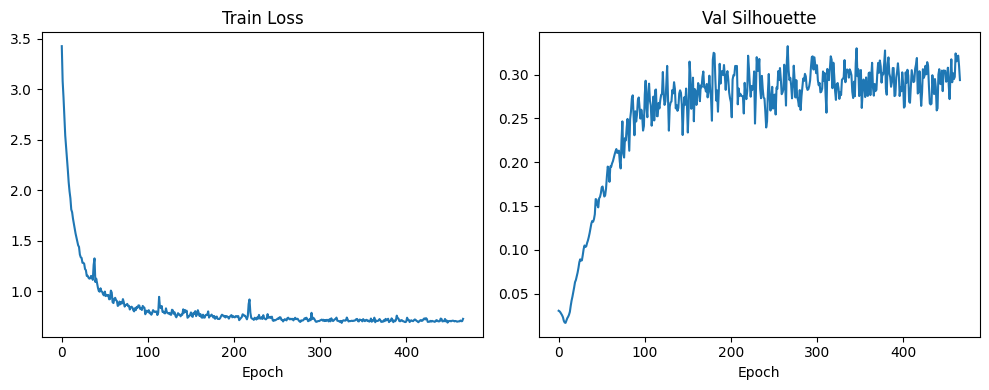

In [71]:
# Create a new figure with a width of 10 inches and height of 4 inches
plt.figure(figsize=(10,4))  

# Activate the first subplot in a 1-row, 2-column grid
plt.subplot(1,2,1)                                                     

# Plot training loss values; set the title to "Train Loss" and x-axis label to "Epoch"
plt.plot(history["train_loss"]); plt.title("Train Loss"); plt.xlabel("Epoch") 

# Activate the second subplot in the same grid
plt.subplot(1,2,2)

# Plot validation silhouette scores; set title to "Val Silhouette" and x-axis label to "Epoch"
plt.plot(history["val_sil"]); plt.title("Val Silhouette"); plt.xlabel("Epoch")

# Automatically adjust subplot spacing, save the figure as training_curves.png, then display it
plt.tight_layout(); plt.savefig(OUTPUT_ROOT / "training_curves.png"); plt.show()  

### Step 13 – Inference with frame‑wise voting + smoothing.

In [72]:
def get_refined_embeddings(model, graph):
    """Extract window‑level speaker embeddings from the trained model."""
    model.eval()                            # Switch to evaluation mode (no dropout/batchnorm updates)
    
    with torch.no_grad():                   # Disable gradient computation for faster inference
        data = graph.to(DEVICE)             # Move the graph (containing mel‑spec windows) to the target device
        _, r_embs, _ = model(data)          # Forward pass; retrieve only the refined embeddings (second output)
    return r_embs.cpu().numpy()            # Convert tensor to CPU, then to NumPy array for clustering


def diarize_agglo(model, graph, n_speakers=4, win_hop=0.75):
    """
    Agglomerative clustering on refined embeddings,
    followed by frame‑wise majority voting over overlapping windows.
    """
    refined = get_refined_embeddings(model, graph)   # (N_windows, emb_dim) array of embeddings
    if refined.shape[0] < n_speakers:                # Not enough windows to form the requested clusters
        return []                                    # Return empty diarization

    # Step 1: cluster the window embeddings
    clust = AgglomerativeClustering(                 # Instantiate agglomerative clustering
        n_clusters=n_speakers, metric='cosine', linkage='average'  # Use cosine distance and average linkage
    )
    cluster_ids = clust.fit_predict(refined)          # Assign each window a cluster label (shape N_windows)

    times = graph.times                               # List of (start_time, end_time) for each window in seconds
    total_end = max(e for _, e in times)              # Latest end time in the audio
    n_frames = int(np.ceil(total_end / FRAME_STEP))   # Total number of 10 ms frames

    # Step 2: collect votes per frame
    # votes[frame_idx] will be a Counter of cluster_id -> count
    from collections import defaultdict, Counter      # Import tools for vote counting
    frame_votes = defaultdict(Counter)                # Map frame index -> Counter of cluster votes

    for idx, (start, end) in enumerate(times):        # Iterate over each window's time span
        cid = cluster_ids[idx]                        # Cluster assigned to this window
        sf = int(start / FRAME_STEP)                  # Start frame index (floor)
        ef = int(end / FRAME_STEP)                    # End frame index (exclusive)
        for f in range(sf, ef):                       # For every frame covered by this window
            if 0 <= f < n_frames:                     # Only consider valid frame indices
                frame_votes[f][cid] += 1              # Add one vote for this cluster at frame f

    # Step 3: assign the most‑voted cluster to each frame
    frame_labels = np.full(n_frames, -1, dtype=int)   # Initialize frame labels with -1 (unassigned)
    
    for f in range(n_frames):                         # Process every frame
        if f in frame_votes:                          # If at least one window covers this frame
            # Select cluster with the most votes; ties are broken by smaller cluster ID
            best_cluster = frame_votes[f].most_common(1)[0][0]
            frame_labels[f] = best_cluster            # Assign the winning speaker
        else:
            # (Frames never covered should not occur if windows cover full audio, but kept for safety)
            pass

    # Step 4: median‑filter smoothing (window = 111 ms -> 11 frames)
    cleaned = np.copy(frame_labels)                   # Save a copy before in‑place smoothing
    win = 11                                          # Smoothing window size in frames (111 ms)
    half = win // 2                                   # Half window for symmetric neighbourhood
    for i in range(n_frames):
        lo = max(0, i - half)                         # Lower bound of local window
        hi = min(n_frames, i + half + 1)              # Upper bound (exclusive)
        counts = Counter(cleaned[lo:hi])              # Count speaker occurrences in the window
        frame_labels[i] = counts.most_common(1)[0][0] # Assign the majority speaker

    # Step 5: convert frame labels to time segments
    segments = []                                     # List to store final diarization segments
    cur_spk = None                                    # Current speaker label
    seg_start = 0                                     # Start frame index of current segment
    
    for i, spk in enumerate(frame_labels):            # Step through frames
        if spk != cur_spk:                            # Speaker change detected
            if cur_spk is not None and i > seg_start: # Close the previous segment (if valid)
                segments.append({
                    "start": seg_start * FRAME_STEP,        # Convert frames back to seconds
                    "end": i * FRAME_STEP,
                    "speaker": f"SPEAKER_{cur_spk:02d}"     # Format speaker ID
                })
            cur_spk = spk                             # Update current speaker
            seg_start = i                             # New segment starts here
            
    if cur_spk is not None and n_frames > seg_start:  # Handle the final segment
        segments.append({
            "start": seg_start * FRAME_STEP,
            "end": n_frames * FRAME_STEP,
            "speaker": f"SPEAKER_{cur_spk:02d}"
        })

    return segments                                   # Return the list of diarization segments


def write_rttm(segments, path, file_id):
    """Write diarization results to an RTTM file."""
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)  # Create output directory if needed
    with open(path, "w") as f:                                 # Open output file for writing
        for seg in segments:                                   # Iterate over each segment
            dur = seg["end"] - seg["start"]                    # Duration of the segment
            if dur < 0.001:                                    # Skip segments shorter than 1 ms
                continue
            f.write(                                           # Write RTTM line
                f"SPEAKER {file_id} 1 {seg['start']:.3f} "
                f"{dur:.3f} <NA> <NA> {seg['speaker']} <NA>\n"
            )

print("Inference ready (voting‑based).")

Inference ready (voting‑based).


### Step 14 – Run Inference on All Tiers.  

In [73]:
ESHARC_RESULTS = {}                      # Dictionary to store the diarization output for each processing tier

for tier_name, graphs in TIER_GRAPHS.items():  # Iterate over each tier and its list of (session_id, graph) pairs
    tier_out = OUTPUT_ROOT / f"ESHARC_{tier_name}"   # Create a subdirectory path for this tier's output
    tier_out.mkdir(exist_ok=True)                    # Ensure the output directory exists (create if missing)
    all_lines = []                                   # Buffer to collect RTTM lines from all sessions in this tier
    tier_segs = {}                                   # Dictionary to hold segmentation results keyed by session ID
    
    for sid, graph in graphs:                        # Process each session and its corresponding graph
        segs = diarize_agglo(model, graph, n_speakers=N_SPEAKERS)  # Run agglomerative diarization on the graph
        if not segs: continue                        # Skip session if diarization produced no segments
        file_id = f"Session_{sid}"                  # Build a unique file identifier for the RTTM file
        rttm_path = str(tier_out / f"session_{sid:02d}.rttm")  # Construct full path for the per‑session RTTM file
        write_rttm(segs, rttm_path, file_id)         # Write the segmentation result to an RTTM file
        with open(rttm_path) as f:                   # Open the just‑written RTTM file for reading
            all_lines.extend(f.readlines())          # Append all its lines to the combined buffer
        tier_segs[sid] = segs                        # Store the segments for later reference
    combined = str(tier_out / f"ESHARC_{tier_name}_combined.rttm")  # Path for the tier‑level combined RTTM file
    
    with open(combined, "w") as f:                   # Open the combined RTTM file for writing
        f.writelines(all_lines)                      # Write all buffered lines into the combined file
    ESHARC_RESULTS[tier_name] = {"session_results": tier_segs, "combined_rttm": combined}  # Save per‑session results and the combined RTTM path
    print(f"{tier_name}: {len(tier_segs)} sessions diarized.")  # Report how many sessions were successfully diarized for this tier

Very_Clean: 10 sessions diarized.
Pink_Noise: 10 sessions diarized.
ER_Noise: 10 sessions diarized.


### Step 15 – Ground‑truth RTTM (if missing).

In [75]:
# ============================================================  
# Step 15 REPLACEMENT — Force-regenerate GT RTTM from real timestamps  
# ============================================================  
                                 
# Force delete and regenerate   
if GT_RTTM.exists():             # Check if the GT RTTM file already exists
    GT_RTTM.unlink()             # Delete the existing file to ensure fresh generation
    print("Deleted stale GT RTTM.")  # Log that the old file was removed
                                 
with open(str(GT_RTTM), "w") as f:  # Open the GT RTTM file for writing (overwrite mode)
    
    for _, row in GT_DF.iterrows(): # Iterate over each row of the ground truth DataFrame
        file_id = f"Session_{int(row['Session_ID'])}"  # Build the file id string from Session_ID
        start   = float(row["Start_Seconds"])          # Extract start time in seconds (float)
        end     = float(row["End_Seconds"])            # Extract end time in seconds (float)
        dur     = end - start                          # Compute segment duration
        
        if dur <= 0:                                   # Skip invalid or zero‑duration segments
            continue                                   # Move to next row
            
        # Clean speaker name: replace spaces and special chars with underscore  
        spk = str(row["Speaker"]).strip()              # Remove leading/trailing whitespace from speaker name
        spk = re.sub(r'[\s\(\)]+', '_', spk).strip('_') # Replace spaces/parentheses with underscores and trim trailing underscores
        f.write(f"SPEAKER {file_id} 1 {start:.3f} {dur:.3f} "  # Write RTTM line with SPEAKER tag, file_id, channel=1, start, duration
                f"<NA> <NA> {spk} <NA>\n")             # Write remaining fields: <NA> <NA> speaker <NA>, ending with newline
                                 
print("GT RTTM regenerated from real timestamps.")     # Confirmation message after successful regeneration
                                 
# Verify  
print("\n=== Verification ===")                       
with open(str(GT_RTTM)) as f:                         # Open the newly created GT RTTM for reading
    lines = f.readlines()                              # Read all lines into a list
print(f"Total lines: {len(lines)}")                   # Show total number of RTTM records
print("First 5 lines:")                               # Header for sample output
for l in lines[:5]: print(" ", l.strip())             # Print first 5 lines (trimmed) for quick inspection
                                 
# Confirm timing matches audio   
ref_check = load_annot(str(GT_RTTM))                  # Load the generated RTTM into pyannote annotation object
for fid in sorted(ref_check)[:3]:                     # Iterate over first three session IDs (sorted)
    end = max(seg.end for seg in ref_check[fid].itersegments())  # Find the latest segment end time for that session
    print(f"  {fid} GT ends at: {end:.1f}s")          # Print session ID and its total duration

Deleted stale GT RTTM.
GT RTTM regenerated from real timestamps.

=== Verification ===
Total lines: 105
First 5 lines:
  SPEAKER Session_1 1 0.000 9.010 <NA> <NA> Doctor_Smith <NA>
  SPEAKER Session_1 1 9.404 6.252 <NA> <NA> Miss_Lopez <NA>
  SPEAKER Session_1 1 16.050 7.669 <NA> <NA> David_Son <NA>
  SPEAKER Session_1 1 24.112 7.481 <NA> <NA> Doctor_Smith <NA>
  SPEAKER Session_1 1 31.986 8.160 <NA> <NA> Nurse_Sarah <NA>
  Session_1 GT ends at: 77.6s
  Session_10 GT ends at: 78.6s
  Session_2 GT ends at: 78.6s


### Step 16 – DER / SER evaluation.

In [76]:
def load_annot(rttm_path):  # Define function to parse RTTM file into pyannote Annotation objects
    ann = {}  # Initialize dictionary to map file IDs to Annotation
    
    with open(rttm_path) as f:  # Open RTTM file for reading
        for line in f:  # Iterate over each line in the file
            parts = line.strip().split()  # Strip whitespace and split line into tokens
            if parts[0] != "SPEAKER": continue  # Skip lines not starting with SPEAKER
            fid, start, dur, spk = parts[1], float(parts[3]), float(parts[4]), parts[7]  # Extract file ID, start time, duration, speaker label
            if fid not in ann:  # If this file ID hasn't been seen yet
                ann[fid] = Annotation(uri=fid)  # Create a new Annotation for the file
            ann[fid][Segment(start, start+dur)] = spk  # Assign speaker label to the time segment
            
    return ann  # Return the dictionary of annotations

def compute_der(ref_rttm, hyp_rttm, collar=0.25):  # Compute Diarization Error Rate between reference and hypothesis RTTMs
    
    ref = load_annot(ref_rttm)  # Load reference annotations
    hyp = load_annot(hyp_rttm)  # Load hypothesis annotations
    common = set(ref) & set(hyp)  # Find recordings present in both reference and hypothesis
    
    if not common: return 100.0  # Return 100% error if no common recordings
    metric = DiarizationErrorRate(collar=collar)  # Initialize DER metric with given forgiveness collar
    tot_err, tot_ref = 0.0, 0.0  # Accumulators for total error time and total reference time
    
    for fid in common:  # For each common recording
        det = metric(ref[fid], hyp[fid], detailed=True)  # Compute detailed error components
        tot_err += det["false alarm"] + det["missed detection"] + det["confusion"]  # Sum all error durations
        tot_ref += det["total"]  # Sum total reference speech duration
        
    return (tot_err / max(tot_ref, 1e-6)) * 100.0  # Return DER as percentage (avoid division by zero)

def compute_ser(ref_rttm, hyp_rttm, collar=0.25):  # Compute Speaker Error Rate (confusion-only part of DER)
    ref = load_annot(ref_rttm)  # Load reference annotations
    hyp = load_annot(hyp_rttm)  # Load hypothesis annotations
    common = set(ref) & set(hyp)  # Find common recordings
    
    if not common: return 100.0  # Return 100% error if no common recordings
    metric = DiarizationErrorRate(collar=collar)  # Initialize DER metric
    tot_con, tot_ref = 0.0, 0.0  # Accumulators for confusion time and total reference time
    
    for fid in common:  # For each common recording
        det = metric(ref[fid], hyp[fid], detailed=True)  # Compute detailed error components
        tot_con += det["confusion"]  # Only accumulate confusion (speaker mislabeling)
        tot_ref += det["total"]  # Sum total reference speech duration
        
    return (tot_con / max(tot_ref, 1e-6)) * 100.0  # Return SER as percentage

eval_rows = []  # Initialize list to collect evaluation results

for tier_name, res in ESHARC_RESULTS.items():  # Loop over each tier in the results dictionary
    der = compute_der(str(GT_RTTM), res["combined_rttm"])  # Compute DER against ground truth
    ser = compute_ser(str(GT_RTTM), res["combined_rttm"])  # Compute SER against ground truth
    eval_rows.append({"Tier": tier_name, "DER (%)": round(der,2), "SER (%)": round(ser,2)})  # Append tier results to list
    print(f"{tier_name}  DER={der:.2f}%  SER={ser:.2f}%")  # Print results for this tier

df_eval = pd.DataFrame(eval_rows)  # Create pandas DataFrame from evaluation rows
df_eval.to_csv(OUTPUT_ROOT / "esharc_der_ser.csv", index=False)  # Save DataFrame to CSV file without row index

Very_Clean  DER=9.77%  SER=7.89%
Pink_Noise  DER=7.01%  SER=5.13%
ER_Noise  DER=5.97%  SER=4.08%


In [14]:
# Import the DiarizationErrorRate metric class from pyannote.metrics
from pyannote.metrics.diarization import DiarizationErrorRate
# Import Annotation and Segment classes from pyannote.core
from pyannote.core import Annotation, Segment

BASE_PATH = Path.cwd()                      # Set BASE_PATH to the current working directory
GT_RTTM = BASE_PATH / "ground_truth.rttm"

def load_annot(rttm_path):
    """
    Parse an RTTM file into a dictionary of pyannote Annotation objects.
    Each key is a file ID (URI), each value is an Annotation holding speaker segments.
    """
    # Initialize an empty dictionary to store Annotations keyed by file ID
    ann = {}
    # Open the RTTM file for reading
    with open(rttm_path) as f:
        # Process each line of the file
        for line in f:
            # Strip trailing whitespace and split the line into tokens
            parts = line.strip().split()
            # Skip lines that do not begin with the SPEAKER keyword
            if parts[0] != "SPEAKER":
                continue
            # Extract file ID, start time, duration, and speaker label from the tokens
            fid, start, dur, spk = parts[1], float(parts[3]), float(parts[4]), parts[7]
            # If this file ID has not yet been encountered, create a new Annotation for it
            if fid not in ann:
                ann[fid] = Annotation(uri=fid)
            # Assign the speaker label to the corresponding time segment [start, start+dur)
            ann[fid][Segment(start, start + dur)] = spk
    # Return the dictionary of annotations
    return ann


def compute_der(ref_rttm, hyp_rttm, collar=0.25):
    """
    Compute the Diarization Error Rate (DER) between reference and hypothesis RTTMs,
    returning the overall DER percentage and a dictionary of error component totals.
    """
    # Load reference annotations from the given RTTM file path
    ref = load_annot(ref_rttm)
    # Load hypothesis annotations from the given RTTM file path
    hyp = load_annot(hyp_rttm)
    # Determine the set of recordings (file IDs) present in both reference and hypothesis
    common = set(ref) & set(hyp)
    # If no common recordings exist, return 100% error and zero components
    if not common:
        return 100.0, {"false alarm": 0.0, "missed detection": 0.0, "confusion": 0.0, "total": 0.0}

    # Instantiate the DER metric with the specified collar (forgiveness window)
    metric = DiarizationErrorRate(collar=collar)
    # Initialize accumulators for total error time and total reference time
    tot_err = 0.0
    tot_ref = 0.0
    # Initialize a dictionary to accumulate the individual error component durations
    components = {"false alarm": 0.0, "missed detection": 0.0, "confusion": 0.0, "total": 0.0}

    # Iterate over every recording that appears in both reference and hypothesis
    for fid in common:
        # Compute detailed error metrics for the current recording
        det = metric(ref[fid], hyp[fid], detailed=True)
        # Add the three error durations (false alarm, missed detection, confusion)
        tot_err += det["false alarm"] + det["missed detection"] + det["confusion"]
        # Add the total reference speech duration for this recording
        tot_ref += det["total"]
        # Accumulate each component into the components dictionary
        for key in ["false alarm", "missed detection", "confusion", "total"]:
            components[key] += det[key]

    # Calculate overall DER as (total error / total reference) * 100%
    der = (tot_err / tot_ref) * 100.0 if tot_ref > 0 else 100.0
    # Return the DER percentage and the dictionary of component totals
    return der, components


# Dictionary mapping tier names to their hypothesis RTTM files
tiers = {
    "Very Clean": "/home/unbukenny/SHARC/Objective4_ESHARC_Outputs_V5/ESHARC_Very_Clean/ESHARC_Very_Clean_combined.rttm",
    "Pink Noise": "/home/unbukenny/SHARC/Objective4_ESHARC_Outputs_V5/ESHARC_Pink_Noise/ESHARC_Pink_Noise_combined.rttm",
    "ER Noise": "/home/unbukenny/SHARC/Objective4_ESHARC_Outputs_V5/ESHARC_ER_Noise/ESHARC_ER_Noise_combined.rttm"
}

# Compute DER and component breakdowns for each tier
for tier_name, hyp_path in tiers.items():
    der, comp = compute_der(GT_RTTM, hyp_path)
    print(f"===== {tier_name} =====")
    print(f"Total DER: {der:.2f}%")
    # Print each component in seconds and as a percentage of total reference speech
    print(f"  False Alarm   : {comp['false alarm']:.2f} s  ({comp['false alarm']/comp['total']*100:.2f}%)")
    print(f"  Missed Det.   : {comp['missed detection']:.2f} s  ({comp['missed detection']/comp['total']*100:.2f}%)")
    print(f"  Confusion     : {comp['confusion']:.2f} s  ({comp['confusion']/comp['total']*100:.2f}%)")
    print(f"  Reference Spk : {comp['total']:.2f} s\n")    

===== Very Clean =====
Total DER: 9.77%
  False Alarm   : 14.35 s  (1.88%)
  Missed Det.   : 0.00 s  (0.00%)
  Confusion     : 60.14 s  (7.89%)
  Reference Spk : 762.40 s

===== Pink Noise =====
Total DER: 7.01%
  False Alarm   : 14.35 s  (1.88%)
  Missed Det.   : 0.00 s  (0.00%)
  Confusion     : 39.13 s  (5.13%)
  Reference Spk : 762.40 s

===== ER Noise =====
Total DER: 5.97%
  False Alarm   : 14.35 s  (1.88%)
  Missed Det.   : 0.00 s  (0.00%)
  Confusion     : 31.13 s  (4.08%)
  Reference Spk : 762.40 s



### Step 17 — DER Comparison Bar Chart (E-SHARC versus Baselines).

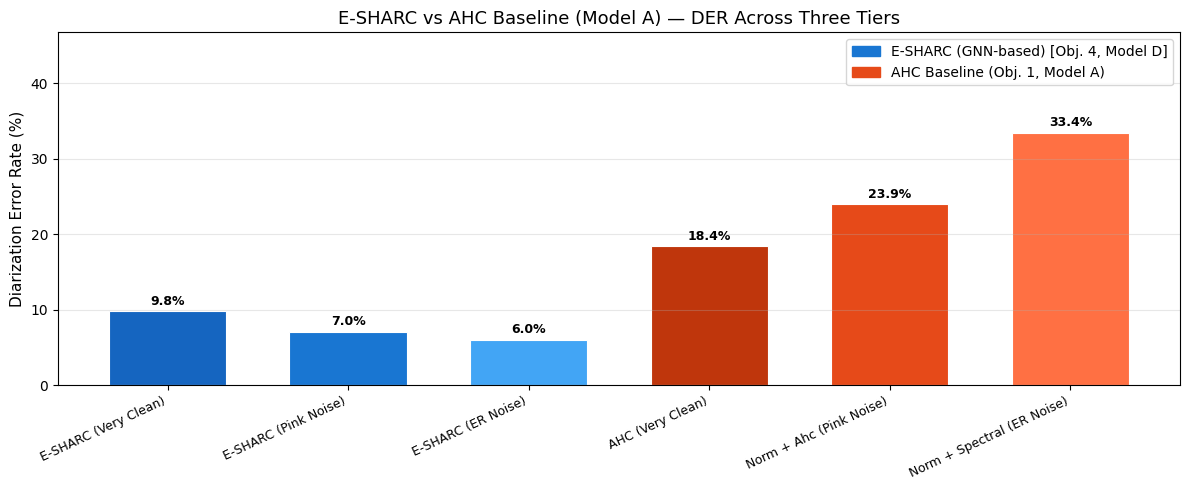

[SAVED] \\wsl.localhost\Ubuntu-22.04\home\unbukenny\SHARC\Objective4_ESHARC_Outputs_V5\esharc_vs_modelA.png


In [23]:
# ============================================================
# OBJECTIVE 4 — VISUALISATION: DER COMPARISON
# E-SHARC vs. baseline (Model A) 
# ============================================================

# ── Hard‑coded DER values ────────────────────────────────
# E‑SHARC results (from Objective 4, Model D)
esharc_values = {
    "Very_Clean": 9.77,      # Tier 1 – Very Clean
    "Pink_Noise": 7.01,      # Tier 2 – Pink Noise
    "ER_Noise"  : 5.97,      # Tier 3 – ER Noise
}

# AHC baseline results (from Objective 1, Model A)
baselines = {
    "AHC (Very Clean)"              : 18.38,   # Tier 1
    "Norm + Ahc (Pink Noise)"       : 23.94,   # Tier 2  (label )
    "Norm + Spectral (ER Noise)"    : 33.38,   # Tier 3
}

# ── Plot setup ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

# Colour schemes – consistent families for E‑SHARC (blue) and baseline (terracotta)
colors_esharc   = {"Very_Clean": "#1565C0",
                   "Pink_Noise": "#1976D2",
                   "ER_Noise"  : "#42A5F5"}
colors_baseline = {"Very Clean": "#BF360C",
                   "Pink Noise": "#E64A19",
                   "ER Noise"  : "#FF7043"}

# Data containers for the bar chart
bar_labels, bar_values, bar_colors = [], [], []

# ── Build E‑SHARC bars ──────────────────────────────────
for tier, der in esharc_values.items():
    # Format the tier name (e.g., "Very_Clean" → "Very Clean") for display
    display_label = f"E-SHARC ({tier.replace('_',' ')})"
    bar_labels.append(display_label)
    bar_values.append(der)
    bar_colors.append(colors_esharc.get(tier, "#1976D2"))   # fallback blue

# ── Build baseline (Model A) bars ───────────────────────
for label, der in baselines.items():
    bar_labels.append(label)
    bar_values.append(der)
    # Extract the noise condition from inside the parentheses, e.g. "Pink Noise"
    key = label.split("(")[1].rstrip(")")
    bar_colors.append(colors_baseline.get(key, "#E64A19"))  # fallback orange

# ── Plotting ─────────────────────────────────────────────
x = np.arange(len(bar_labels))
bars = ax.bar(x, bar_values, color=bar_colors, edgecolor="white",
              linewidth=0.8, width=0.65)

# Annotate each bar with its DER percentage
for bar, val in zip(bars, bar_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold")

# X‑axis labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(bar_labels, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Diarization Error Rate (%)", fontsize=11)
ax.set_title("E-SHARC vs AHC Baseline (Model A) — DER Across Three Tiers", fontsize=13)

# Y‑axis limits with headroom above the tallest bar
ax.set_ylim(0, max(bar_values) * 1.25 + 5)
ax.grid(axis="y", alpha=0.3)

# Legend – distinguish the two methods
legend_patches = [
    mpatches.Patch(color="#1976D2", label="E-SHARC (GNN-based) [Obj. 4, Model D]"),
    mpatches.Patch(color="#E64A19", label="AHC Baseline (Obj. 1, Model A)"),
]
ax.legend(handles=legend_patches, loc="upper right", fontsize=10)

# ── Save and display ─────────────────────────────────────
plt.tight_layout()
fig_path = OUTPUT_ROOT / "esharc_vs_modelA.png"
plt.savefig(str(fig_path), dpi=150)
plt.show()
plt.close("all")
print(f"[SAVED] {fig_path}")

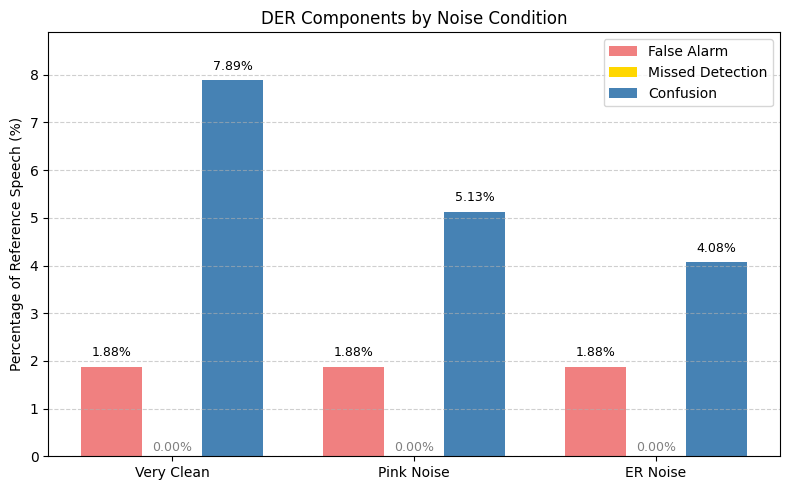

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Tier labels (x-axis categories)
tiers = ["Very Clean", "Pink Noise", "ER Noise"]

# Percentage values for each component (from the provided data)
false_alarm = [1.88, 1.88, 1.88]
missed_det  = [0.00, 0.00, 0.00]
confusion   = [7.89, 5.13, 4.08]


# Set up bar positions
x = np.arange(len(tiers))          # [0, 1, 2]
bar_width = 0.25                    # width of each bar group
gap = 0.02                          # optional gap between groups

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Plot each component as a separate group of bars
bars_fa = ax.bar(x - bar_width, false_alarm, bar_width,
                 label="False Alarm", color="lightcoral")
bars_md = ax.bar(x, missed_det, bar_width,
                 label="Missed Detection", color="gold")
bars_cf = ax.bar(x + bar_width, confusion, bar_width,
                 label="Confusion", color="steelblue")

# Annotate each bar with its percentage value
def add_labels(bars):
    """Attach a text label above each bar, displaying its height."""
    for bar in bars:
        height = bar.get_height()
        # Only show label if height > 0, otherwise display "0.00" slightly above zero
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.15,
                    f"{height:.2f}%", ha='center', va='bottom', fontsize=9)
        else:
            # For zero-height bars, place text just above the axis
            ax.text(bar.get_x() + bar.get_width()/2., 0.05,
                    "0.00%", ha='center', va='bottom', fontsize=9, color='gray')

add_labels(bars_fa)
add_labels(bars_md)
add_labels(bars_cf)

# Axis labels and title
ax.set_ylabel("Percentage of Reference Speech (%)")
ax.set_title("DER Components by Noise Condition")
ax.set_xticks(x)
ax.set_xticklabels(tiers)
ax.legend()

# Adjust y-axis to accommodate labels
max_val = max(max(false_alarm), max(confusion))
ax.set_ylim(0, max_val + 1.0)

# Add a faint horizontal grid for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

# Tight layout and display
plt.tight_layout()
fig_path = OUTPUT_ROOT / "esharc_DER_breakdown.png"
plt.savefig(str(fig_path), dpi=150)
plt.show()

### Step 18 — t-SNE Visualisation of R-GNN Refined Embeddings.


[t-SNE] Tier: Very_Clean


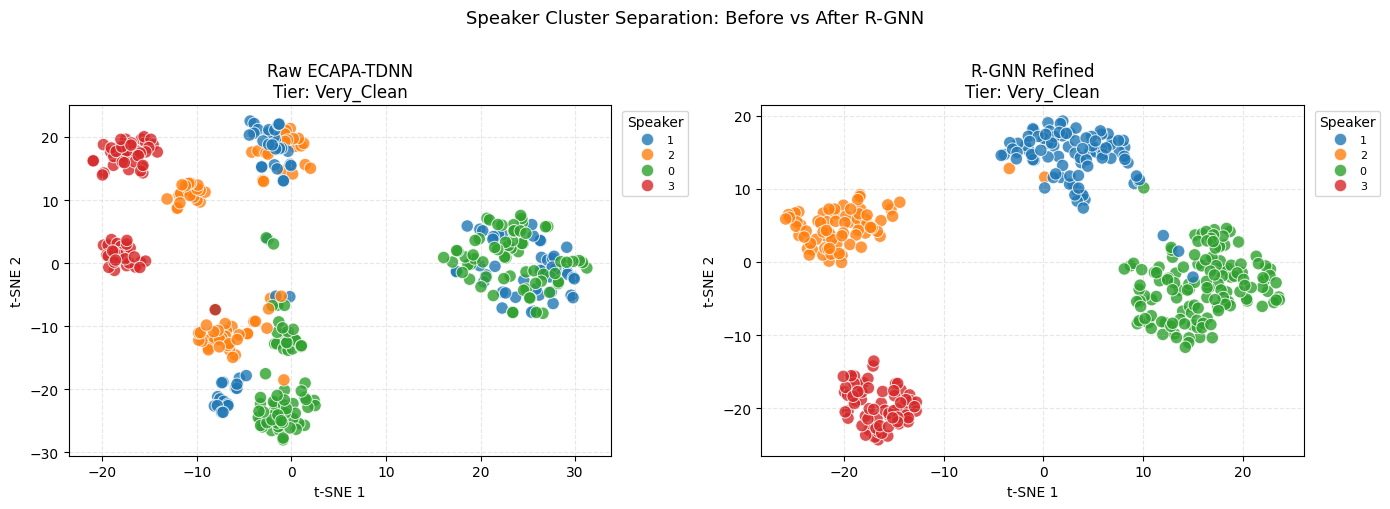

  [SAVED] \\wsl.localhost\Ubuntu-22.04\home\unbukenny\SHARC\Objective4_ESHARC_Outputs_V5\esharc_tsne_Very_Clean.png
  Silhouette raw  : 0.0685
  Silhouette R-GNN: 0.6747   (up improvement)

[t-SNE] Tier: Pink_Noise


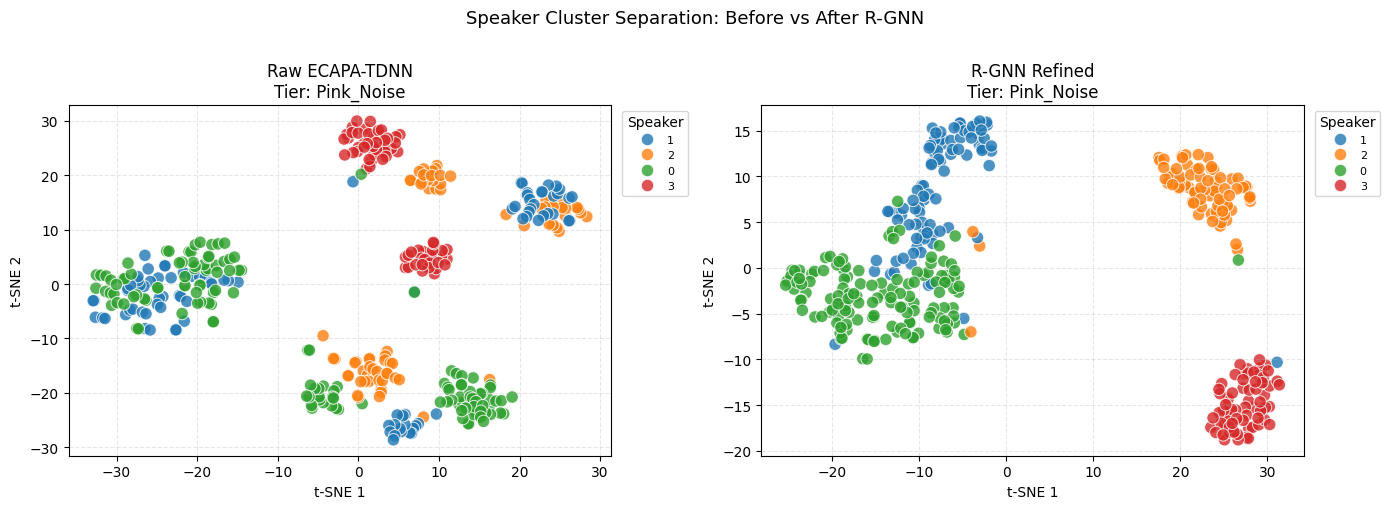

  [SAVED] \\wsl.localhost\Ubuntu-22.04\home\unbukenny\SHARC\Objective4_ESHARC_Outputs_V5\esharc_tsne_Pink_Noise.png
  Silhouette raw  : 0.0734
  Silhouette R-GNN: 0.5529   (up improvement)

[t-SNE] Tier: ER_Noise


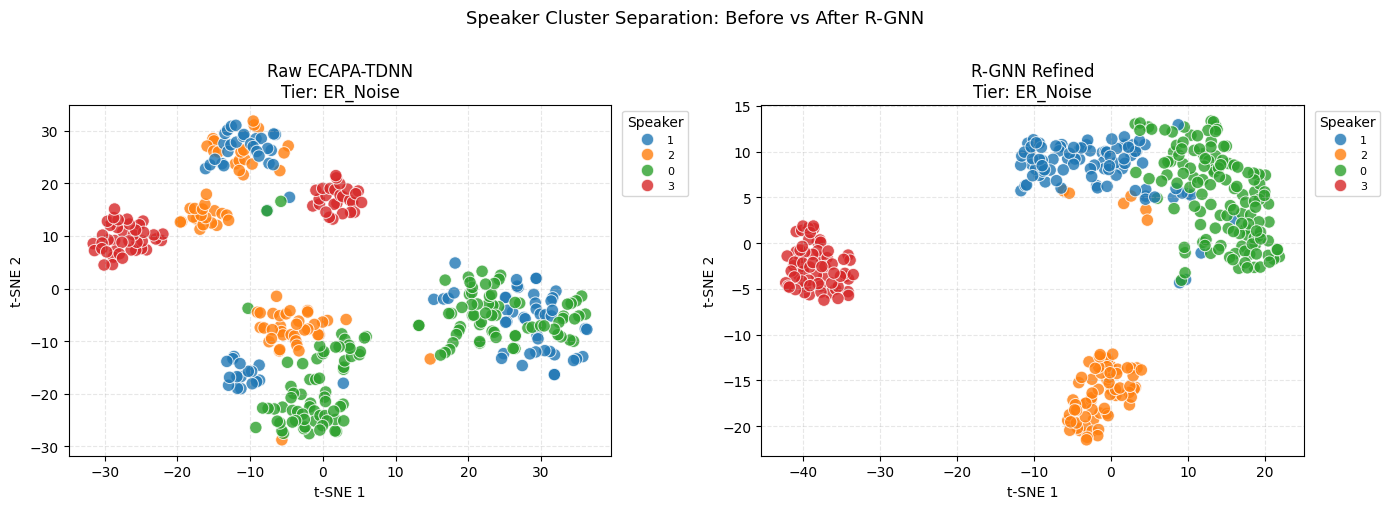

  [SAVED] \\wsl.localhost\Ubuntu-22.04\home\unbukenny\SHARC\Objective4_ESHARC_Outputs_V5\esharc_tsne_ER_Noise.png
  Silhouette raw  : 0.0608
  Silhouette R-GNN: 0.5705   (up improvement)


In [80]:
# ============================================================
# OBJECTIVE 4 — t-SNE: BEFORE versus AFTER R-GNN REFINEMENT
# Demonstrates that the R-GNN pulls same-speaker nodes closer.
# ============================================================

# Import t-SNE dimensionality reduction tool from scikit-learn
from sklearn.manifold import TSNE

def plot_tsne_before_after(tier_name, graphs, model, device=DEVICE,
                            n_sessions=3):
    """
    Plot t-SNE for raw ECAPA embeddings vs R-GNN refined embeddings
    side-by-side for the first n_sessions sessions of a tier.
    """
    # Lists to accumulate embeddings and labels across sessions
    raw_all, ref_all, lab_all = [], [], []

    # Set model to evaluation mode (no dropout, no gradient tracking)
    model.eval()
    # Disable gradient computation for memory efficiency
    
    with torch.no_grad():
        # Iterate over the first n_sessions graphs (each representing a session)
        for idx, (sid, graph) in enumerate(graphs[:n_sessions]):
            # Move graph data to the specified device (CPU or GPU, but it is CPU here)
            data = graph.to(device)
            # Forward pass through R-GNN; only the refined embeddings (ref) are needed
            _, ref, _ = model(data)
            # Select only nodes that have a valid label (y >= 0)
            valid = data.y >= 0

            # Skip sessions with fewer than 5 labeled nodes (unstable t-SNE)
            if valid.sum() < 5:
                continue

            # Store raw ECAPA embeddings, refined embeddings, and labels
            raw_all.append(data.x[valid].cpu().numpy())
            ref_all.append(ref[valid].cpu().numpy())
            lab_all.append(data.y[valid].cpu().numpy())

    # If no valid nodes were collected, exit early
    if not raw_all:
        print(f"  [SKIP] No valid labeled nodes for {tier_name}")
        return

    # Stack all collected arrays into single matrices
    raw_all = np.vstack(raw_all)
    ref_all = np.vstack(ref_all)
    lab_all = np.concatenate(lab_all)

    # Determine perplexity for t-SNE: heuristic based on number of samples
    perp = min(30, max(2, len(lab_all) // 3))
    # Initialize t-SNE with PCA initialization, fixed random seed for reproducibility
    tsne = TSNE(n_components=2, perplexity=perp, random_state=SEED,
                init="pca", learning_rate="auto")

    # Compute 2D embeddings for raw features and for refined features separately
    raw2d = tsne.fit_transform(raw_all)
    ref2d = tsne.fit_transform(ref_all)

    # Create a figure with two side-by-side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loop over both axes: left for raw, right for refined
    for ax, emb2d, title in [(ax1, raw2d, "Raw ECAPA-TDNN"),
                              (ax2, ref2d, "R-GNN Refined")]:
        # Scatter plot: points colored by speaker label (as string for discrete hues)
        sns.scatterplot(x=emb2d[:,0], y=emb2d[:,1], hue=lab_all.astype(str),
                        palette="tab10", s=80, alpha=0.8, edgecolor="w",
                        ax=ax)
        # Set subplot title and axis labels
        ax.set_title(f"{title}\nTier: {tier_name}", fontsize=12)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        # Place legend outside the plot for clarity
        ax.legend(title="Speaker", bbox_to_anchor=(1.01,1), loc="upper left",
                  fontsize=8)
        # Add a light grid for readability
        ax.grid(True, alpha=0.3, linestyle="--")

    # Overall figure title (slightly above the subplots)
    plt.suptitle("Speaker Cluster Separation: Before vs After R-GNN",
                 fontsize=13, y=1.01)
    # Automatically adjust subplot spacing
    plt.tight_layout()
    # Build save path using the global OUTPUT_ROOT and tier name
    save_path = OUTPUT_ROOT / f"esharc_tsne_{tier_name}.png"
    # Save figure with high-ish DPI and tight bounding box
    plt.savefig(str(save_path), dpi=150, bbox_inches="tight")
    # Display the plot (if running interactively)
    plt.show()
    # Close all figure handles to free memory
    plt.close("all")
    print(f"  [SAVED] {save_path}")

    # Compute silhouette scores to quantitatively compare cluster separation
    if len(np.unique(lab_all)) > 1:
        # Cosine metric is appropriate for embedding vectors (direction-based)
        sil_raw = silhouette_score(raw_all, lab_all, metric="cosine")
        sil_ref = silhouette_score(ref_all, lab_all, metric="cosine")
        print(f"  Silhouette raw  : {sil_raw:.4f}")
        # Indicate whether refinement improved the silhouette score
        print(f"  Silhouette R-GNN: {sil_ref:.4f}  ",
              f"({'up' if sil_ref > sil_raw else 'down'} improvement)")

# -------------------------------------------------------------------
# Loop over all tiers present in the global TIER_GRAPHS dictionary
for tier_name in TIER_GRAPHS:
    # Only process tiers that have at least one graph
    if TIER_GRAPHS[tier_name]:
        print(f"\n[t-SNE] Tier: {tier_name}")
        # Call the plotting function for this tier, using the global MODEL
        plot_tsne_before_after(tier_name, TIER_GRAPHS[tier_name], model)

### Step 18 — Diarization Timeline: E-SHARC versus Ground Truth.


[TIMELINE] Tier: Very_Clean


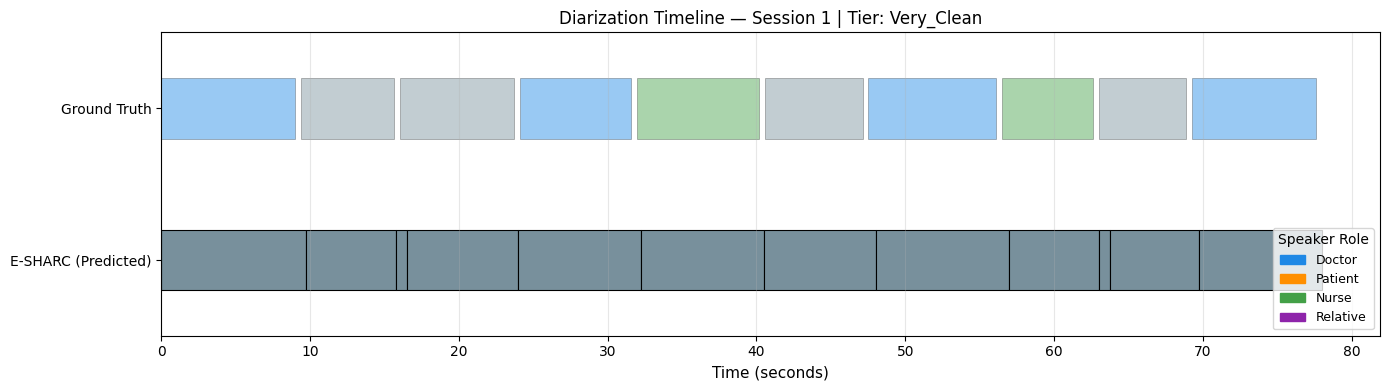

   Session 1: 12 predicted segments | saved.


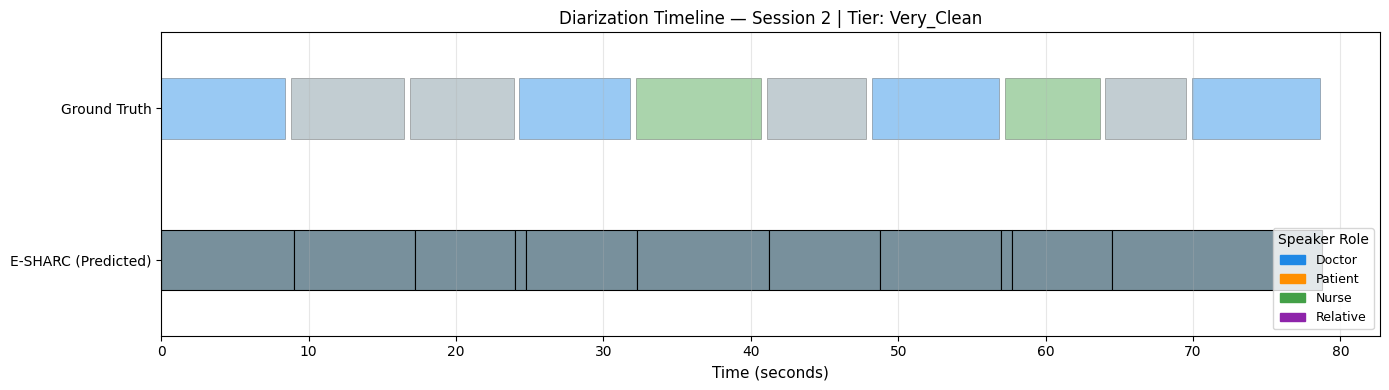

   Session 2: 11 predicted segments | saved.


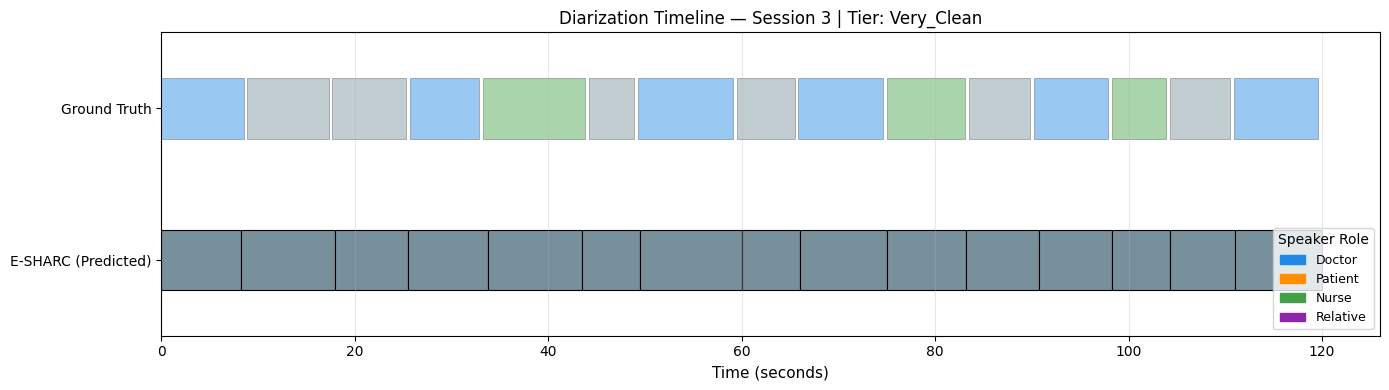

   Session 3: 15 predicted segments | saved.

[TIMELINE] Tier: Pink_Noise


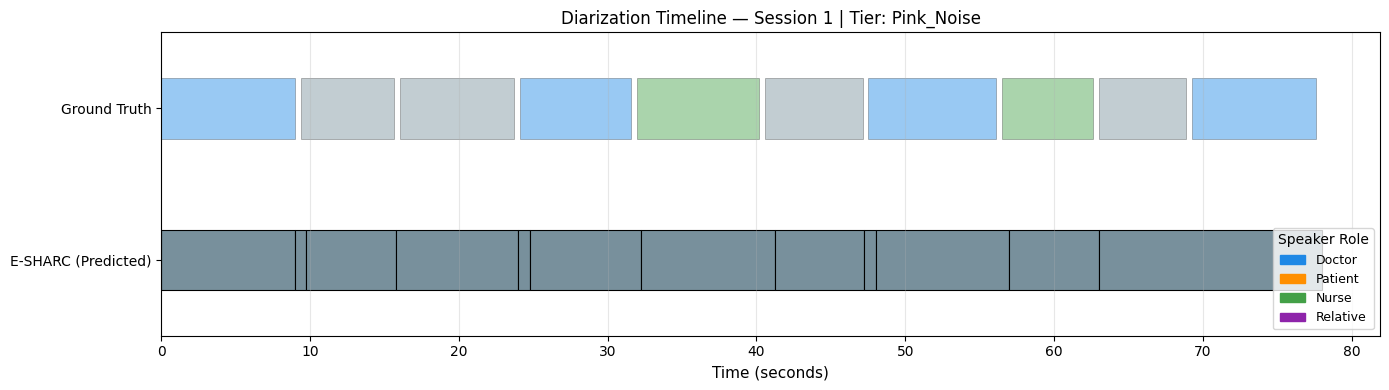

   Session 1: 12 predicted segments | saved.


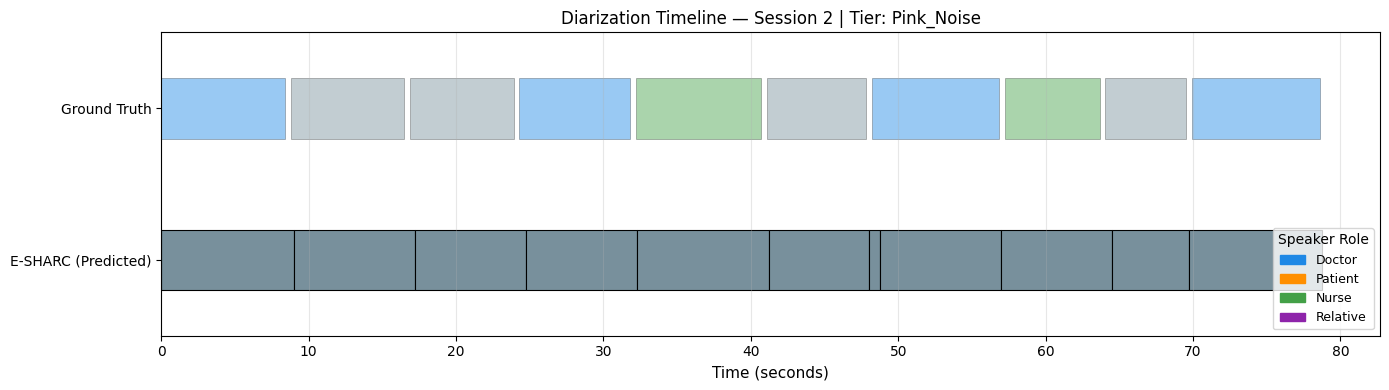

   Session 2: 11 predicted segments | saved.


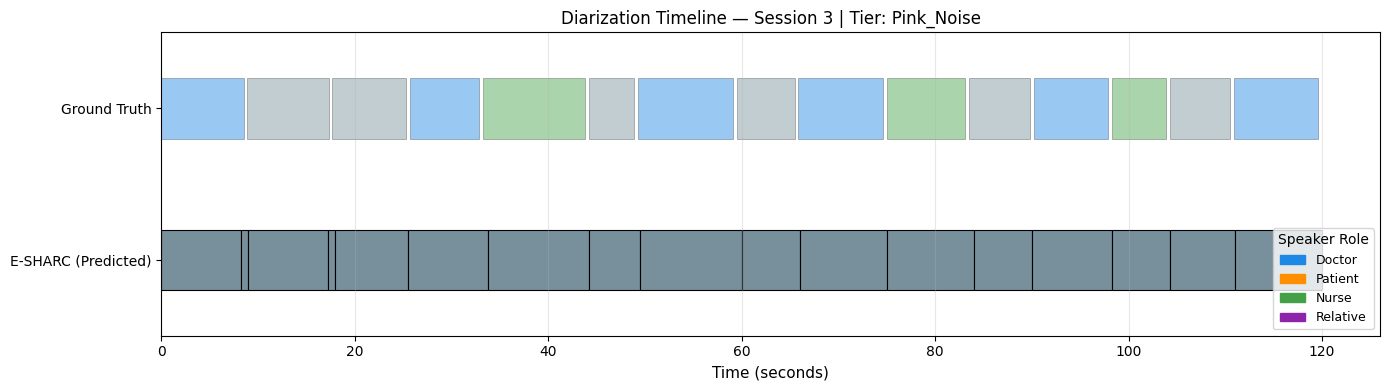

   Session 3: 17 predicted segments | saved.

[TIMELINE] Tier: ER_Noise


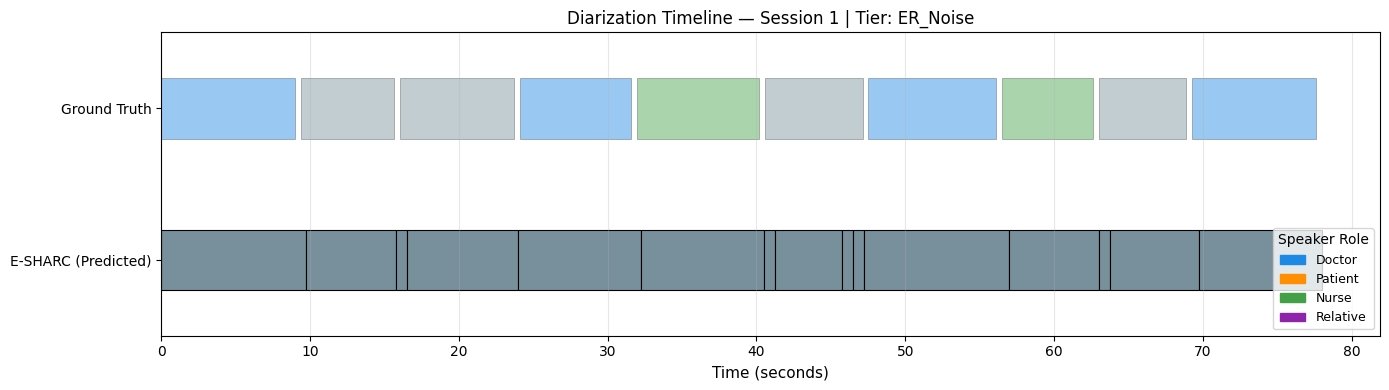

   Session 1: 15 predicted segments | saved.


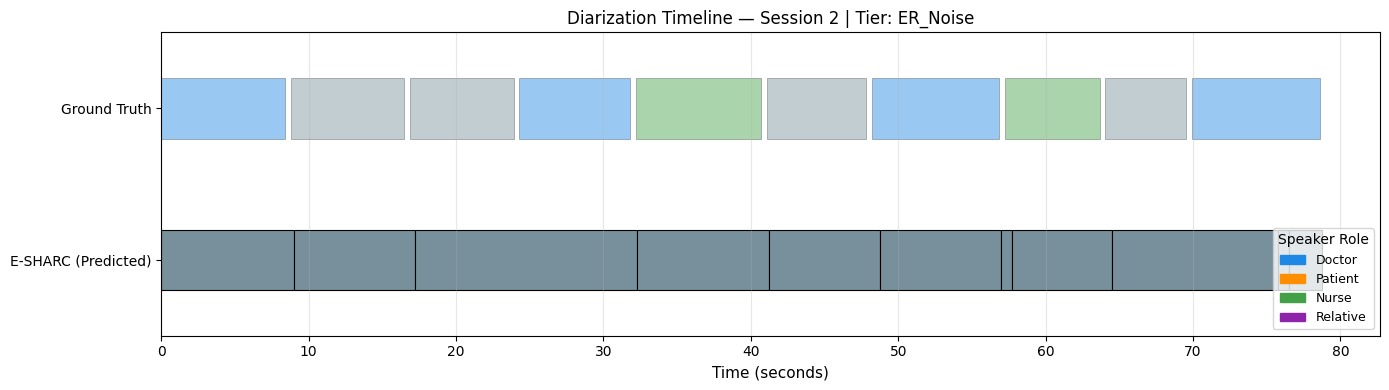

   Session 2: 11 predicted segments | saved.


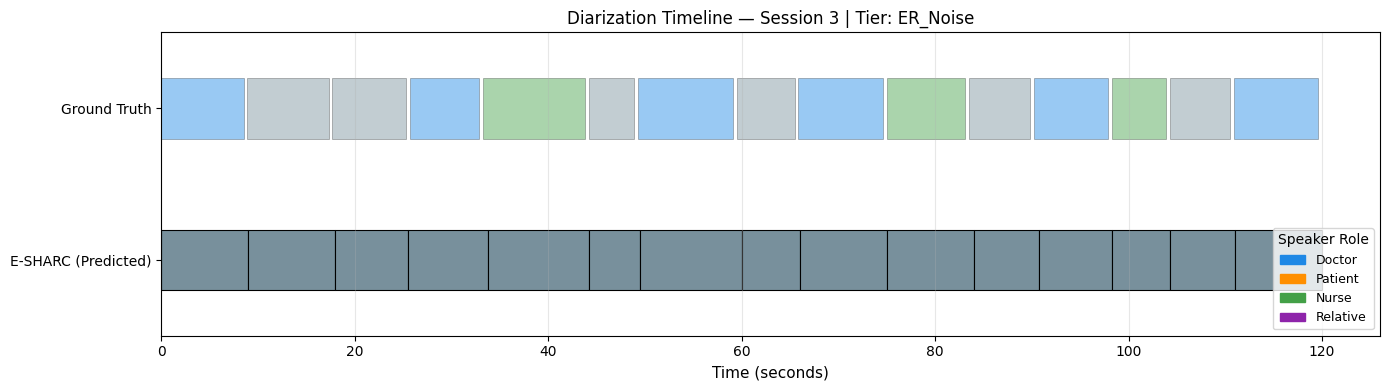

   Session 3: 15 predicted segments | saved.


In [85]:
# ============================================================  
# OBJECTIVE 4 — TIMELINE VISUALISATION                         
# Plot E-SHARC output against ground truth for selected sessions.  
# ============================================================  
  
# Dictionary mapping speaker roles to their display colors  
ROLE_COLORS = {                                               
    "Doctor"   : "#1E88E5",   # Blue                          # Role color entry: Doctor -> blue
    "Patient"  : "#FF8F00",   # Orange                        # Role color entry: Patient -> orange
    "Nurse"    : "#43A047",   # Green                         # Role color entry: Nurse -> green
    "Relative" : "#8E24AA"    # Purple                        # Role color entry: Relative -> purple
}                                                             
FALLBACK_COLOR = "#78909C"   # blue-grey for unknown/unmatched speakers  
 
def role_color(speaker_name: str) -> str:                     # Function definition: take speaker name, return color hex
    """Return colour hex code for a speaker based on their role (case‑insensitive)."""  
    
    for role, color in ROLE_COLORS.items():                   # Iterate over each role and its color
        if role.lower() in str(speaker_name).lower():         # Check if role (lowercased) is substring of speaker name (lowercased)
            return color                                      # Return the matching color
    return FALLBACK_COLOR                                     # If no match, return fallback color
    
  
def gt_segments_for_session(gt_df: pd.DataFrame, session_id: int) -> list:  # Function to extract GT segments for one session
    """Extract ground truth segments for a specific session, sorted by start time."""  
    sub = gt_df[gt_df["Session_ID"] == session_id].sort_values("Start_Seconds")  # Filter rows by session ID and sort by start time
    
    return [{"start": float(r["Start_Seconds"]),             # Build list of dicts with start, end, speaker
             "end":   float(r["End_Seconds"]),                 # Convert end time to float
             "speaker": str(r["Speaker"])} for _, r in sub.iterrows()]  # Iterate over rows, converting types
 
def plot_diarization_timeline_esharc(pred_segs, gt_segs,      # Function to plot timeline comparison
                                      session_id, tier_name, save_path):  # Parameters: predicted segments, GT segments, session ID, tier name, save path
    """Horizontal bar timeline comparing predicted vs. ground truth diarization.""" 
    fig, ax = plt.subplots(figsize=(14, 4))                  # Create figure and axis with specified size
 
    # Draw ground truth segments (semi-transparent) on the upper row (y=1) 
    for seg in gt_segs:                                      # Iterate over each ground truth segment
        
        ax.barh(1, seg["end"] - seg["start"], left=seg["start"],  # Draw horizontal bar at y=1, width = duration, left edge = start time
                height=0.4, color=role_color(seg["speaker"]),  # Bar height, color based on speaker role
                alpha=0.45, edgecolor="black", linewidth=0.4)  # Semi-transparent, black border
 
    # Draw predicted segments (opaque) on the lower row (y=0)  
    for seg in pred_segs:                                    # Iterate over predicted segments
        
        # Predicted labels like "SPEAKER_00" won't match any role → fallback grey  # Explanation of color fallback
        ax.barh(0, seg["end"] - seg["start"], left=seg["start"],  # Draw bar at y=0
                height=0.4, color=role_color(seg["speaker"]),  # Color via same function (likely grey)
                edgecolor="black", linewidth=0.8)            # Opaque, black border
        
 
    # Adjust y-axis limits so bars are not clipped and look centred 
    ax.set_ylim(-0.5, 1.5)                                         # Set y-axis range from -0.5 to 1.5
  # (blank line)
    # Set y‑tick labels and positions                         # Label the two rows
    ax.set_yticks([0, 1])                                     # Ticks at y=0 and y=1
    ax.set_yticklabels(["E-SHARC (Predicted)", "Ground Truth"], fontsize=10)  # Custom labels
 
    # Axis labels and title                                   
    ax.set_xlabel("Time (seconds)", fontsize=11)              # X-axis label
    ax.set_title(f"Diarization Timeline — Session {session_id} | Tier: {tier_name}",  # Title with session and tier info
                 fontsize=12)                                 # Title font size
  
    # Legend showing only the speaker roles (ground truth colours)  
    patches = [mpatches.Patch(color=v, label=k) for k, v in ROLE_COLORS.items()]  # Create colored patch for each role
    ax.legend(handles=patches, loc="lower right",             # Add legend at lower right
              title="Speaker Role", fontsize=9)               # Legend title and font size
 
    # Light vertical grid for readability                     
    ax.grid(axis="x", alpha=0.3)                              # Vertical grid lines, semi-transparent
    plt.tight_layout()                                        # Adjust layout to prevent clipping
  
    # Save and display                             
    plt.savefig(save_path, dpi=150)                           # Save figure to file with 150 dpi
    plt.show()                                                # Display the plot
    plt.close("all")                                          # Close all figures to free memory

# ── Render timelines for first 3 sessions of each tier ───  
for tier_name, res in ESHARC_RESULTS.items():                 # Iterate over each tier and its results
    tier_out = OUTPUT_ROOT / f"ESHARC_{tier_name}"            # Build output directory path
    tier_out.mkdir(exist_ok=True)                             # Create directory if not exists

    print(f"\n[TIMELINE] Tier: {tier_name}")                  # Print tier name header
    for sid in sorted(res["session_results"].keys())[:3]:     # For first three session IDs (sorted)
        pred_segs = res["session_results"][sid]               # Get predicted segments for this session
        gt_segs   = gt_segments_for_session(GT_DF, sid)       # Get ground truth segments for same session
  
        if not gt_segs:                                       # If no ground truth segments found
            print(f"   [SKIP] No GT segments for session {sid}")  # Print skip message
            continue                                          # Go to next session
  
        save_path = str(tier_out / f"timeline_session_{sid:02d}.png")  # Define output file path
        plot_diarization_timeline_esharc(pred_segs, gt_segs,  # Call the plotting function
                                          sid, tier_name, save_path)  # Pass session id, tier name, save path
        print(f"   Session {sid}: {len(pred_segs)} predicted segments | saved.")  # Confirmation message

### Step 19 - Speaker Count Accuracy versus Ground Truth.

      Tier  Session  GT Speakers  Predicted Speakers  Error
Very_Clean        1            4                   4      0
Very_Clean        2            4                   4      0
Very_Clean        3            4                   4      0
Very_Clean        4            4                   4      0
Very_Clean        5            4                   4      0
Very_Clean        6            4                   4      0
Very_Clean        7            4                   4      0
Very_Clean        8            4                   4      0
Very_Clean        9            4                   4      0
Very_Clean       10            4                   4      0
Pink_Noise        1            4                   4      0
Pink_Noise        2            4                   4      0
Pink_Noise        3            4                   4      0
Pink_Noise        4            4                   4      0
Pink_Noise        5            4                   4      0
Pink_Noise        6            4        

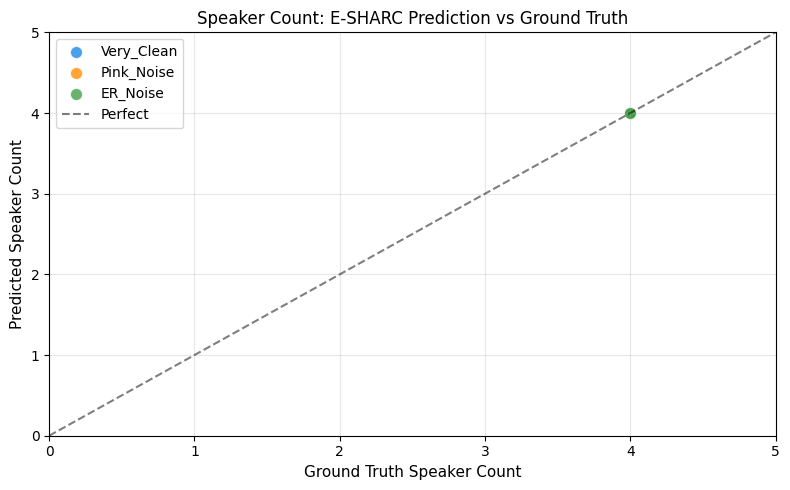

[SAVED] \\wsl.localhost\Ubuntu-22.04\home\unbukenny\SHARC\Objective4_ESHARC_Outputs_V5\esharc_speaker_count.png


In [86]:
# ============================================================
# OBJECTIVE 4 — SPEAKER COUNT ANALYSIS
# Compare predicted number of speakers to ground truth.
# ============================================================

count_rows = []                              # list to collect per‑session speaker count comparisons

# Loop over each evaluation tier (e.g., Very_Clean, Pink_Noise, ER_Noise)
for tier_name, res in ESHARC_RESULTS.items():                 # iterate over each tier's results
    for sid, segs in res["session_results"].items():          # iterate over each session in this tier
        # Number of distinct predicted speakers (set comprehension)
        pred_n = len({s["speaker"] for s in segs})            # count unique predicted speaker labels
        # Ground‑truth unique speakers for this session
        gt_n   = GT_DF[GT_DF["Session_ID"] == sid]["Speaker"].nunique()  # count unique ground-truth speakers for the session

        count_rows.append({                                   # store this session's speaker count comparison
            "Tier"              : tier_name,                  # evaluation condition name
            "Session"           : sid,                        # session identifier
            "GT Speakers"       : int(gt_n),                  # ground-truth speaker count as integer
            "Predicted Speakers": pred_n,                     # predicted speaker count
            "Error"             : abs(pred_n - int(gt_n))     # absolute difference between counts
        })

# Build a clean DataFrame
df_counts = pd.DataFrame(count_rows)                          # create DataFrame from the collected rows
print(df_counts.to_string(index=False))                       # print full DataFrame without row indices
print("\nMean |error| per tier:")                             # header for per‑tier error summary
print(df_counts.groupby("Tier")["Error"].mean().round(2))     # print mean absolute error per tier, rounded to 2 decimals

# ── Scatter plot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))                        # create a figure and axes with specified size
palette = {"Very_Clean": "#1E88E5", "Pink_Noise": "#FF8F00", "ER_Noise": "#43A047"}  # colour map for each tier

for tier in df_counts["Tier"].unique():                       # loop over each tier present in the DataFrame
    sub = df_counts[df_counts["Tier"] == tier]                # subset of rows belonging to this tier
    ax.scatter(sub["GT Speakers"], sub["Predicted Speakers"], # plot ground-truth vs predicted speaker counts
               label=tier, color=palette.get(tier, "grey"),   # legend label and marker colour (fallback grey)
               s=80, alpha=0.8, edgecolors="w")               # marker size, transparency, and white edge

# Determine axis limit: 1 above the maximum observed count in either axis
max_val = max(df_counts[["GT Speakers", "Predicted Speakers"]].max()) + 1  # compute symmetric axis limit
# Perfect‑prediction diagonal (from 0 to max_val)
ax.plot([0, max_val], [0, max_val], "k--", alpha=0.5, label="Perfect")  # diagonal line for perfect predictions

ax.set_xlabel("Ground Truth Speaker Count", fontsize=11)      # x‑axis label
ax.set_ylabel("Predicted Speaker Count", fontsize=11)         # y‑axis label
ax.set_title("Speaker Count: E-SHARC Prediction vs Ground Truth", fontsize=12)  # plot title
ax.legend(fontsize=10)                                        # add legend with specified font size
ax.grid(True, alpha=0.3)                                      # enable grid with mild transparency

# Optionally enforce equal aspect ratio and same axis limits
ax.set_xlim(0, max_val)                                       # set x‑axis limits from 0 to max_val
ax.set_ylim(0, max_val)                                       # set y‑axis limits to match

fig_path = OUTPUT_ROOT / "esharc_speaker_count.png"           # construct full file path for the output plot
plt.tight_layout()                                            # adjust layout to prevent clipping
plt.savefig(str(fig_path), dpi=150)                           # save the figure at 150 DPI
plt.show()                                                    # display the plot
plt.close("all")                                              # close all figure windows to free memory
print(f"[SAVED] {fig_path}")                                  # confirm the file was saved

### Step 20 - C-GNN Merge Score Distribution Analysis.

  Optimal threshold (max F1): 0.10  F1=0.7884
  (Updated CFG['merge_threshold'] = 0.10)


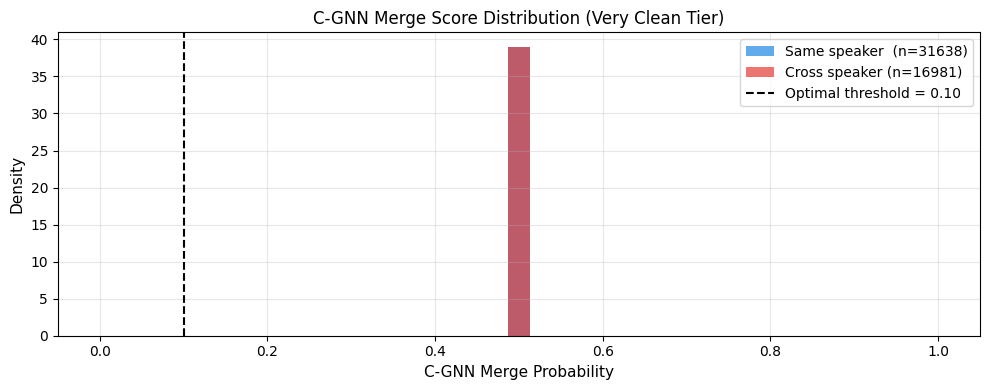

[SAVED] \\wsl.localhost\Ubuntu-22.04\home\unbukenny\SHARC\Objective4_ESHARC_Outputs_V5\esharc_merge_score_distribution.png


In [87]:
# ============================================================
# OBJECTIVE 4 — MERGE SCORE DISTRIBUTION                        
# Visualise how well C-GNN separates same-speaker edges from    
# cross-speaker edges (calibration of the learned threshold).   
# ============================================================  

@torch.no_grad()                                                # Disable gradient computation for efficiency during inference
def collect_edge_scores(model, graphs, device=DEVICE):          # Function to collect edge scores for same and cross speaker edges
    """
    Returns two lists: scores for same-speaker edges and cross-speaker edges.
    """
    same_scores  = []                                           # List to store probabilities of same‑speaker edges
    cross_scores = []                                           # List to store probabilities of cross‑speaker edges
    model.eval()                                                # Set model to evaluation mode (disable dropout, etc.)

    for _, graph in graphs:                                     # Iterate over each graph (ignore index)
        data = graph.to(device)                                # Move graph data to the target device (CPU)
        
        # model returns (scores, r_embs, spk_logits) – scores is only needed
        scores, _, _ = model(data)                             # Forward pass; keep only edge merge scores
        probs = torch.sigmoid(scores).cpu().numpy()           # Convert raw scores to probabilities and move to CPU as numpy

        e_labels, valid = edge_labels_from_nodes(data.edge_index, data.y)  # Get edge labels (1 = same speaker) and a validity mask
        v = valid.cpu().numpy()                                 # Convert validity mask to numpy array
        l = e_labels.cpu().numpy()                              # Convert edge labels to numpy array

        same_scores.extend(probs[v & (l == 1)].tolist())        # Collect probabilities of valid same‑speaker edges
        cross_scores.extend(probs[v & (l == 0)].tolist())       # Collect probabilities of valid cross‑speaker edges

    return np.array(same_scores), np.array(cross_scores)        # Return both lists as numpy arrays


# Use Very_Clean graphs for a clean calibration plot                 
vc_graphs = TIER_GRAPHS.get("Very_Clean", [])                   # Retrieve graphs from the 'Very_Clean' tier (empty list if missing)
if vc_graphs:                                                   # Proceed only if Very_Clean graphs are available
    
    # Collect all same/cross probabilities from the model on those graphs
    same_s, cross_s = collect_edge_scores(model, vc_graphs)              # Gather same‑speaker and cross‑speaker probabilities

    # ----- Compute optimal threshold by F1 maximisation -----
    from sklearn.metrics import f1_score                        # Import F1 metric for threshold optimisation
    all_scores = np.concatenate([same_s, cross_s])              # Combine all probabilities into a single array
    all_labels = np.concatenate([np.ones(len(same_s)),          # Create label vector: 1 for same‑speaker edges
                                  np.zeros(len(cross_s))])     # and 0 for cross‑speaker edges
    
    best_t, best_f1 = 0.5, 0.0                                  # Initialise best threshold and best F1 score
    for t in np.linspace(0.1, 0.9, 81):                        # Scan 81 thresholds from 0.1 to 0.9
        f1 = f1_score(all_labels, (all_scores >= t).astype(int),  # Compute F1 for current threshold
                      zero_division=0)                           # Avoid undefined metric warning when a class is absent
        
        if f1 > best_f1:                                        # Keep the threshold that yields the highest F1
            best_f1, best_t = f1, t                             # Update best F1 and the corresponding threshold

    print(f"  Optimal threshold (max F1): {best_t:.2f}  F1={best_f1:.4f}")  # Report the optimal threshold and its F1
    
    # Store the threshold in the global configuration
    CFG["merge_threshold"] = best_t                             # Save best threshold into global configuration
    print(f"  (Updated CFG['merge_threshold'] = {best_t:.2f})") # Confirm the update

    # ----- Plot distribution with the optimal threshold -----
    fig, ax = plt.subplots(figsize=(10, 4))                     # Create a wide figure and axes
    bins = np.linspace(0, 1, 40)                                # 40 uniform bins between 0 and 1
    
    ax.hist(same_s,  bins=bins, alpha=0.7, color="#1E88E5",     # Histogram of same‑speaker probabilities (blue)
            label=f"Same speaker  (n={len(same_s)})",  density=True)  # Label with count; normalise to density
    
    ax.hist(cross_s, bins=bins, alpha=0.7, color="#E53935",     # Histogram of cross‑speaker probabilities (red)
            label=f"Cross speaker (n={len(cross_s)})", density=True)  # Label with count; normalise to density
    
    ax.axvline(best_t, color="black", linestyle="--",           # Vertical dashed line at the optimal threshold
               label=f"Optimal threshold = {best_t:.2f}")       # Label for the threshold line
    
    ax.set_xlabel("C-GNN Merge Probability", fontsize=11)       # X‑axis label
    ax.set_ylabel("Density", fontsize=11)                       # Y‑axis label
    ax.set_title("C-GNN Merge Score Distribution (Very Clean Tier)", fontsize=12)  # Plot title
    
    ax.legend(fontsize=10)                                      # Show legend with smaller font
    ax.grid(True, alpha=0.3)                                    # Light grid for readability

    fig_path = OUTPUT_ROOT / "esharc_merge_score_distribution.png"  # Output file path
    plt.tight_layout()                                          # Adjust spacing to avoid clipping
    plt.savefig(str(fig_path), dpi=150)                         # Save figure at 150 DPI
    plt.show()                                                  # Display the plot
    plt.close("all")                                            # Close all windows to free memory
    print(f"[SAVED] {fig_path}")                                # Confirm that the file was saved
    
else:                                                           # No Very_Clean graphs available
    
    print("[SKIP] No Very_Clean graphs available for score distribution plot.")  # Inform the user of the skip

### Step 21 — Comprehensive Results Summary.

In [88]:
# ============================================================
# OBJECTIVE 4 — FINAL RESULTS SUMMARY
# Combined table covering all three tiers with DER, SER,
# speaker count accuracy, and silhouette quality.
# ============================================================

summary_rows = []                        # will hold one dict per tier

# Process each tier using the stored ESHARC_RESULTS dictionary
for tier_name, res in ESHARC_RESULTS.items():
    hyp_rttm  = res["combined_rttm"]     # path to the combined hypothesis RTTM

    # Diarization Error Rate (DER) and Speaker Error Rate (SER)
    # (using the functions defined in Step 16, collar = 0.25)
    der_val = compute_der(str(GT_RTTM), hyp_rttm)
    ser_val = compute_ser(str(GT_RTTM), hyp_rttm)

    # ---- Speaker count accuracy ----
    # filter the per-session count errors computed in Step 19
    sub_counts = df_counts[df_counts["Tier"] == tier_name]
    exact_match = (sub_counts["Error"] == 0).mean() * 100

    # ---- Silhouette score on R-GNN refined embeddings ----
    ref_embs, ref_labs = [], []          # accumulate embeddings + speaker labels
    model.eval()                         # evaluation mode
    with torch.no_grad():                # no gradient computation
        for _, graph in TIER_GRAPHS.get(tier_name, []):
            data  = graph.to(DEVICE)
            # model returns (scores, r_embs, spk_logits); r_embs (second) are wanted.
            _, re, _ = model(data)       # re = refined embeddings
            valid = data.y >= 0          # keep only labelled nodes
            ref_embs.append(re[valid].cpu().numpy())
            ref_labs.append(data.y[valid].cpu().numpy())

    sil = 0.0
    if ref_embs:
        re_cat = np.vstack(ref_embs)     # combine all sessions' embeddings
        rl_cat = np.concatenate(ref_labs)
        if len(np.unique(rl_cat)) > 1:
            sil = round(silhouette_score(re_cat, rl_cat, metric="cosine"), 4)

    # Assemble one row for the summary table
    summary_rows.append({
        "Tier"                : tier_name,
        "DER (%)"             : round(der_val, 2),
        "SER (%)"             : round(ser_val, 2),
        "Spk Count Acc (%)"   : round(exact_match, 1),
        "R-GNN Silhouette"    : sil,
        "Sessions"            : len(res["session_results"]),
    })

# Build DataFrame and display
df_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 70)
print("  OBJECTIVE 4 — E-SHARC FINAL RESULTS")
print("=" * 70)
print(df_summary.to_string(index=False))
print("=" * 70)

# Persist the summary table
csv_path = OUTPUT_ROOT / "esharc_final_summary.csv"
df_summary.to_csv(str(csv_path), index=False)
print(f"\n[SAVED] Summary CSV: {csv_path}")
print(f"[SAVED] All outputs  : {OUTPUT_ROOT}")


  OBJECTIVE 4 — E-SHARC FINAL RESULTS
      Tier  DER (%)  SER (%)  Spk Count Acc (%)  R-GNN Silhouette  Sessions
Very_Clean     9.77     7.89              100.0            0.5542        10
Pink_Noise     7.01     5.13              100.0            0.5896        10
  ER_Noise     5.97     4.08              100.0            0.6096        10

[SAVED] Summary CSV: \\wsl.localhost\Ubuntu-22.04\home\unbukenny\SHARC\Objective4_ESHARC_Outputs_V5\esharc_final_summary.csv
[SAVED] All outputs  : \\wsl.localhost\Ubuntu-22.04\home\unbukenny\SHARC\Objective4_ESHARC_Outputs_V5


# COMPARISON OF THE FOUR MODELS (OBJECTIVES) AND FURTHER VISUALIZATIONS OF ALL THE MODELS.

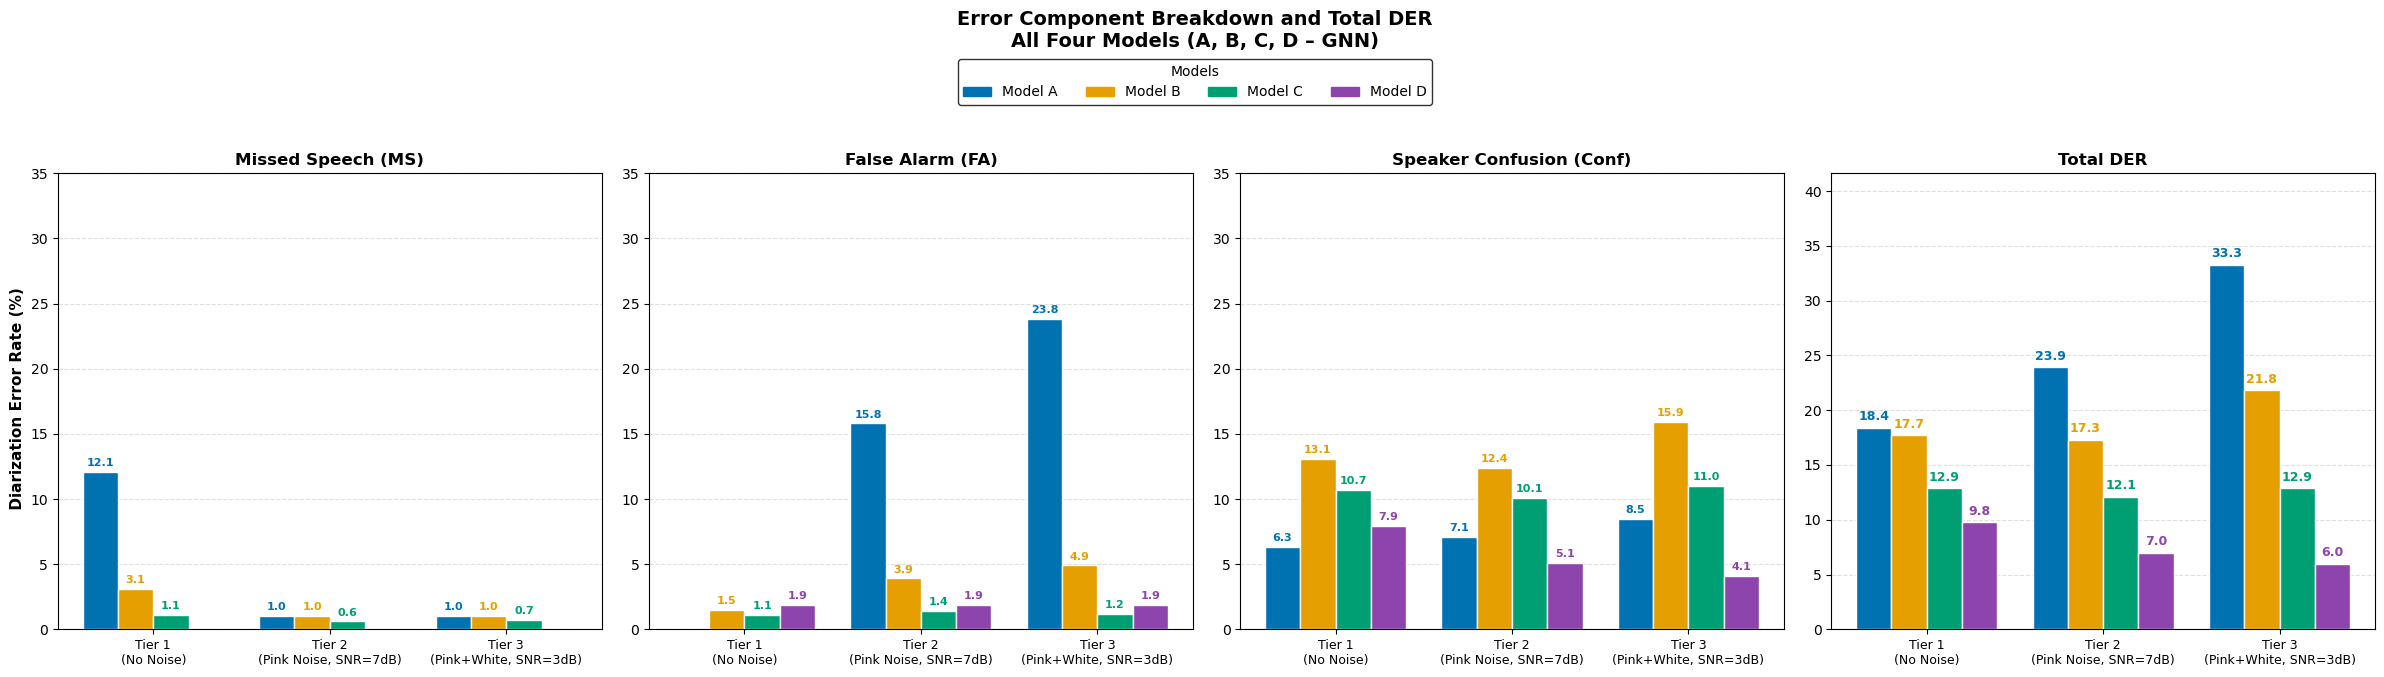

Final 4‑panel chart (A/B/C/D) saved to:
   /home/unbukenny/SHARC/Objective4_ESHARC_Outputs_V5/DER_Components_All_Models.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from pathlib import Path  

BASE_PATH = Path.cwd()  
OUTPUT_ROOT = BASE_PATH / "Objective4_ESHARC_Outputs_V5"  # Root directory for all output files
OUTPUT_ROOT.mkdir(exist_ok=True) 


# ------------------------------------------------------------------
# 1. DATA – All models with component breakdowns
# ------------------------------------------------------------------
# rounding the figures up to the nearest 10th
MODEL_A_COMP = {
    "Tier 1\n(No Noise)":          {"MS": 12.1,  "FA": 0.0,  "Conf": 6.3},
    "Tier 2\n(Pink Noise, SNR=7dB)":    {"MS": 1.0,   "FA": 15.8, "Conf": 7.1},
    "Tier 3\n(Pink+White, SNR=3dB)": {"MS": 1.0,   "FA": 23.8, "Conf": 8.5},
}
MODEL_B_COMP = {
    "Tier 1\n(No Noise)":          {"MS": 3.1, "FA": 1.5, "Conf": 13.1},
    "Tier 2\n(Pink Noise, SNR=7dB)":    {"MS": 1.0, "FA": 3.9, "Conf": 12.4},
    "Tier 3\n(Pink+White, SNR=3dB)": {"MS": 1.0, "FA": 4.9, "Conf": 15.9},
}
MODEL_C_COMP = {
    "Tier 1\n(No Noise)":          {"MS": 1.1,  "FA": 1.1,  "Conf": 10.7},
    "Tier 2\n(Pink Noise, SNR=7dB)":    {"MS": 0.6,  "FA": 1.4,  "Conf": 10.1},
    "Tier 3\n(Pink+White, SNR=3dB)": {"MS": 0.7,  "FA": 1.2,  "Conf": 11.0},  
}
MODEL_D_COMP = {
    "Tier 1\n(No Noise)":          {"MS": 0.0,  "FA": 1.9, "Conf": 7.9},
    "Tier 2\n(Pink Noise, SNR=7dB)":    {"MS": 0.0,  "FA": 1.9, "Conf": 5.1},
    "Tier 3\n(Pink+White, SNR=3dB)": {"MS": 0.0,  "FA": 1.9, "Conf": 4.1},
}


# ------------------------------------------------------------------
# 2. META‑DATA
# ------------------------------------------------------------------
CONDITIONS = list(MODEL_A_COMP.keys())   # 3 acoustic conditions
ERROR_TYPES = [
    ("Missed Speech (MS)",     "MS"),
    ("False Alarm (FA)",       "FA"),
    ("Speaker Confusion (Conf)","Conf"),
]

# Model colours
MODEL_COLORS = {
    "Model A": "#0072B2",   # blue
    "Model B": "#E69F00",   # orange
    "Model C": "#009E73",   # green
    "Model D": "#8E44AD",   # purple
}
MODELS = [
    ("Model A", MODEL_A_COMP),
    ("Model B", MODEL_B_COMP),
    ("Model C", MODEL_C_COMP),
    ("Model D", MODEL_D_COMP),
]
N_MODELS = len(MODELS)

# ------------------------------------------------------------------
# 3. FIGURE LAYOUT – 4 subplots (MS, FA, Conf, Total)
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=False)
bar_width = 0.20
x = np.arange(len(CONDITIONS))

# ------------------------------------------------------------------
# 4. COMPONENT SUBPLOTS (panels 0, 1, 2)
# ------------------------------------------------------------------
for ax, (error_label, error_key) in zip(axes[:3], ERROR_TYPES):
    for j, (model_name, comp_dict) in enumerate(MODELS):
        vals = [comp_dict[cond][error_key] for cond in CONDITIONS]
        xpos = x + (j - N_MODELS/2 + 0.5) * bar_width
        bars = ax.bar(xpos, vals, bar_width,
                      color=MODEL_COLORS[model_name], edgecolor='white',
                      label=model_name if error_key == "MS" else "")  # label once

        # Annotate each bar (skip if value is 0.0 to avoid clutter)
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.3,
                        f"{val:.1f}", ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color=MODEL_COLORS[model_name])

    ax.set_title(error_label, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CONDITIONS, fontsize=9)
    ax.set_ylim(0, 35)          # enough headroom for all values
    ax.grid(axis='y', ls='--', alpha=0.4)
    ax.set_axisbelow(True)
    if ax == axes[0]:
        ax.set_ylabel(" Diarization Error Rate (%)", fontsize=11, fontweight='bold')

# ------------------------------------------------------------------
# 5. TOTAL DER SUBPLOT (panel 3)
# ------------------------------------------------------------------
ax_total = axes[3]

# Total DER = sum of components (or you could use pre‑computed totals)
totals = {}
for model_name, comp_dict in MODELS:
    totals[model_name] = {
        cond: comp_dict[cond]["MS"] + comp_dict[cond]["FA"] + comp_dict[cond]["Conf"]
        for cond in CONDITIONS
    }

for j, model_name in enumerate(totals.keys()):
    vals = [totals[model_name][cond] for cond in CONDITIONS]
    xpos = x + (j - N_MODELS/2 + 0.5) * bar_width
    bars = ax_total.bar(xpos, vals, bar_width,
                        color=MODEL_COLORS[model_name], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax_total.text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 0.4,
                      f"{val:.1f}", ha='center', va='bottom',
                      fontsize=9, fontweight='bold', color=MODEL_COLORS[model_name])

ax_total.set_title("Total DER", fontsize=12, fontweight='bold')
ax_total.set_xticks(x)
ax_total.set_xticklabels(CONDITIONS, fontsize=9)
# Set y-limit dynamically
all_total_vals = [v for d in totals.values() for v in d.values()]
ax_total.set_ylim(0, max(all_total_vals) * 1.25)
ax_total.grid(axis='y', ls='--', alpha=0.4)
ax_total.set_axisbelow(True)

# ------------------------------------------------------------------
# 6. LEGEND (single, across all panels)
# ------------------------------------------------------------------
model_patches = [mpatches.Patch(color=MODEL_COLORS[name], label=name) for name in MODEL_COLORS]
fig.legend(handles=model_patches, title='Models', loc='upper center',
           ncol=4, frameon=True, edgecolor='black', bbox_to_anchor=(0.5, 1.05))

# ------------------------------------------------------------------
# 7. SUPER‑TITLE & SAVE
# ------------------------------------------------------------------
fig.suptitle("Error Component Breakdown and Total DER\n"
             "All Four Models (A, B, C, D – GNN)",
             fontsize=14, fontweight='bold', y=1.12)

plt.tight_layout()

  
output_path = OUTPUT_ROOT / "DER_Components_All_Models.png"

plt.savefig(str(output_path), dpi=300, bbox_inches='tight')
plt.show()
plt.close('all')

print(f"Final 4‑panel chart (A/B/C/D) saved to:\n   {output_path}")

## Reading the Silhoutte and Speakers Result(SSR) from Model A Pipeline

In [21]:
import pandas as pd

import pandas as pd

df = pd.read_csv("/home/unbukenny/SHARC/Objective4_ESHARC_Outputs_V5/Silhoutte_speaker_t1_t2_t3combined_session_results.csv")
df

,Tier,Session_ID,Num_Speakers,Silhouette_Score
0,Tier 1,1,4,0.621377
1,Tier 1,2,4,0.510343
2,Tier 1,3,4,0.514191
3,Tier 1,4,3,0.582023
4,Tier 1,5,3,0.573886
5,Tier 1,6,4,0.594164
6,Tier 1,7,4,0.480142
7,Tier 1,8,3,0.456786
8,Tier 1,9,4,0.597746
9,Tier 1,10,3,0.512918


## Model A Pipeline Silhouette Scores(Best DER Tiers), Per-Session DER Results.

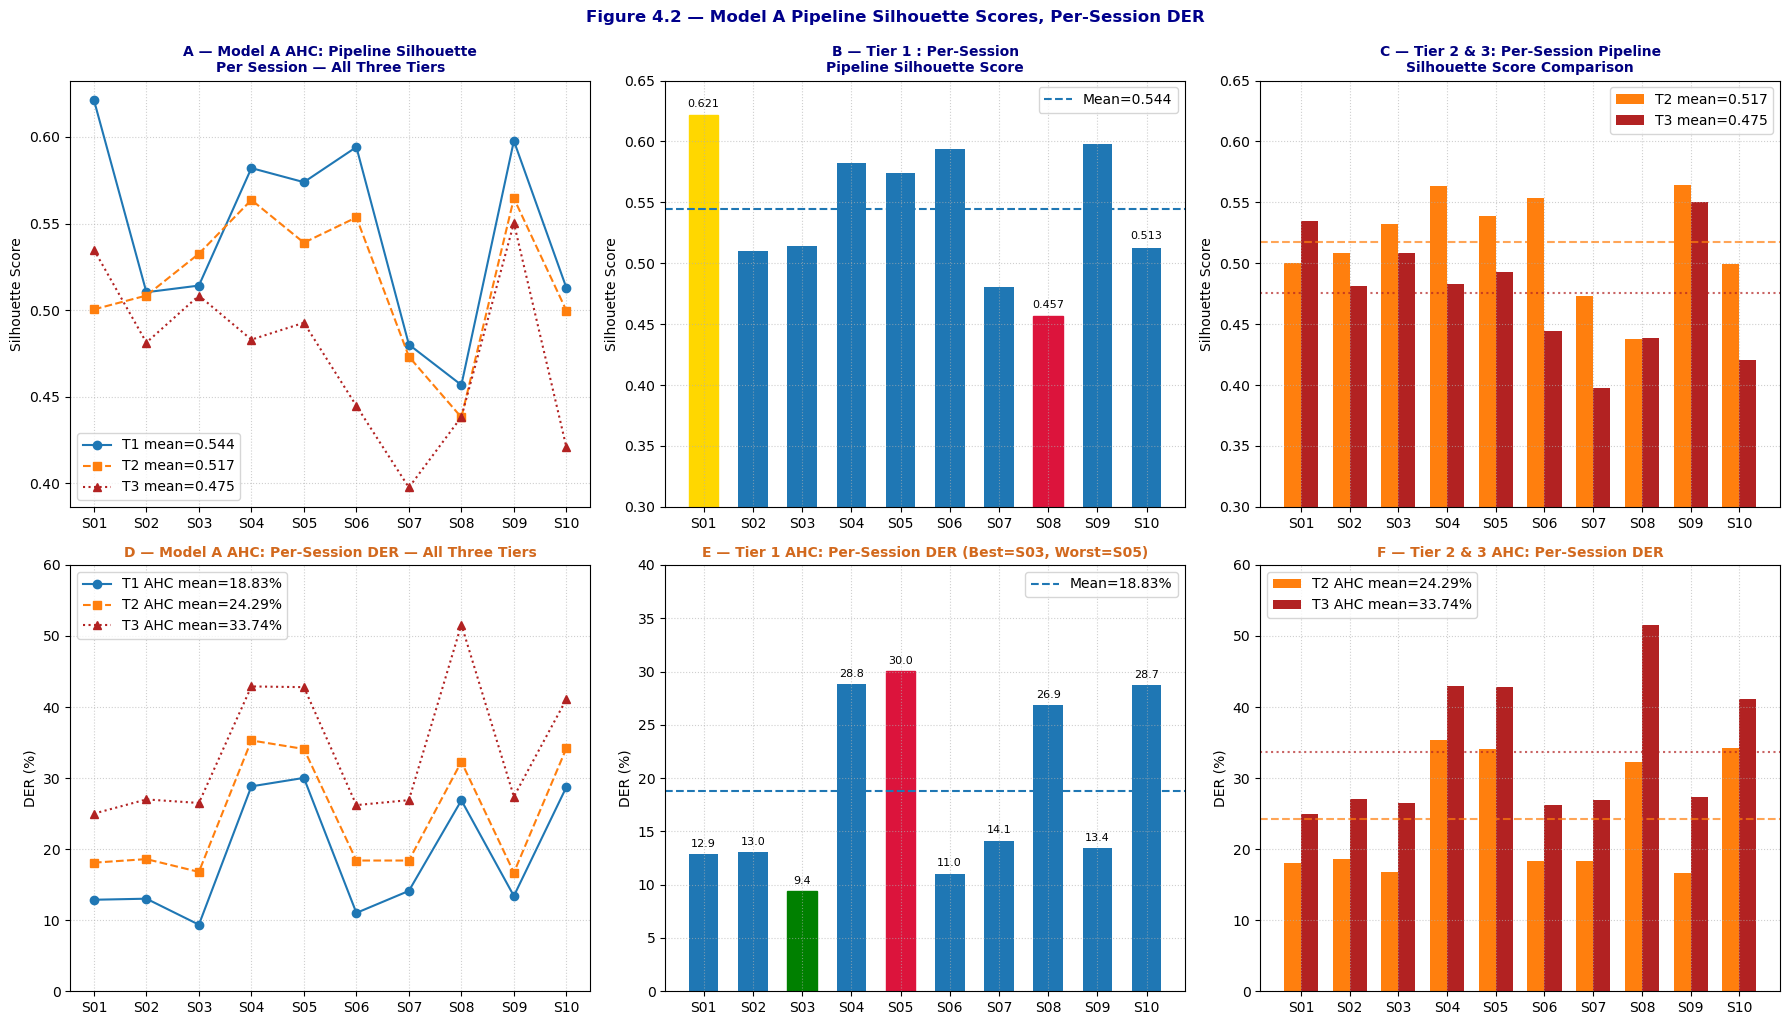

Plot saved successfully to: /home/unbukenny/SHARC/Objective4_ESHARC_Outputs_V5/figure_4.2_Silhoutte_analysis_model_c_grid.png


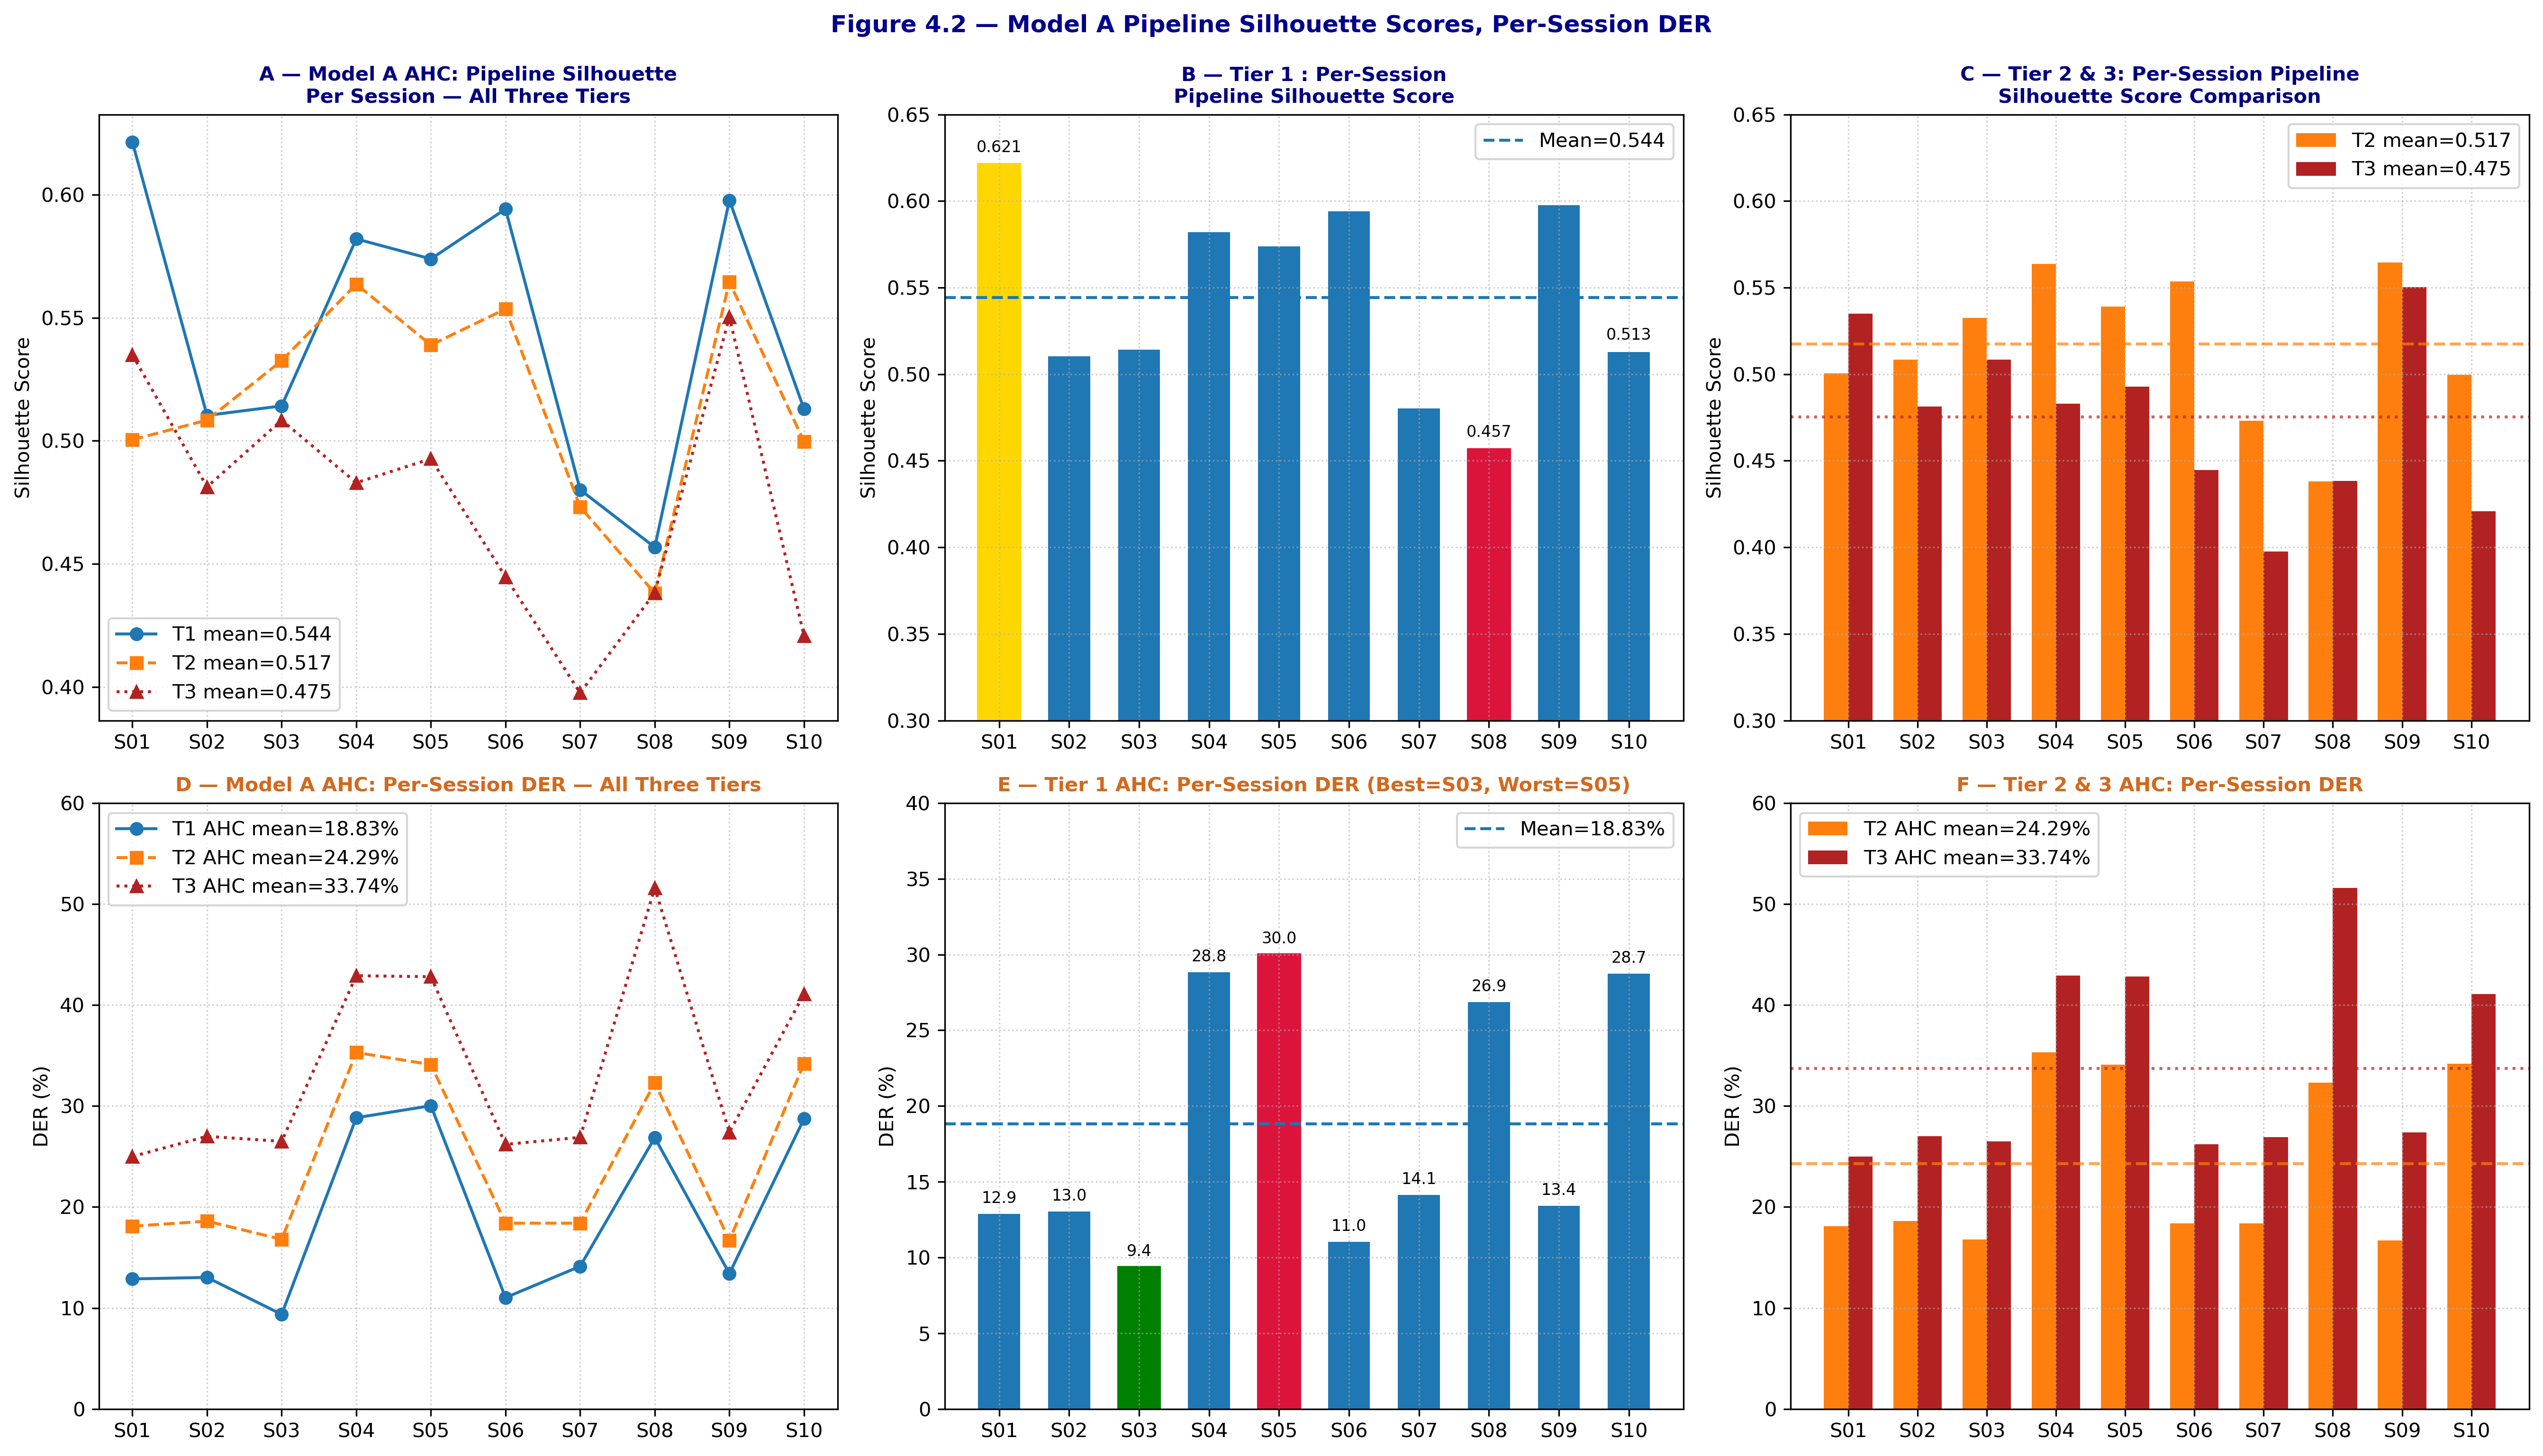

In [28]:
from pathlib import Path  # Object-oriented file system paths for handling directories and file locations
import numpy as np        # Numerical computing library for array manipulation and mathematical operations
import matplotlib.pyplot as plt  # Plotting framework for creating static, animated, and interactive visualizations
from IPython.display import Image, display  # Tools to render and display images directly within Jupyter/IPython notebooks

# 1. Define Path Variables
BASE_PATH = Path.cwd()                        # Get the current working directory as a Path object
OUTPUT_ROOT = BASE_PATH / "Objective4_ESHARC_Outputs_V5" # Define the target directory for saving outputs
OUTPUT_ROOT.mkdir(exist_ok=True)             # Create the output directory if it does not already exist

output_filename = OUTPUT_ROOT / "figure_4.2_Silhoutte_analysis_model_c_grid.png" # Set the absolute path for the output image file

# 2. Define Dataset
sessions = [f"S{i:02d}" for i in range(1, 11)] # Generate zero-padded session labels from 'S01' to 'S10'
t1_sil = [0.621377, 0.510343, 0.514191, 0.582023, 0.573886, 0.594164, 0.480142, 0.456786, 0.597746, 0.512918] # Silhouette scores for Tier 1 across sessions
t2_sil = [0.500438, 0.508435, 0.532584, 0.563635, 0.538936, 0.553558, 0.473191, 0.438115, 0.564546, 0.499731] # Silhouette scores for Tier 2 across sessions
t3_sil = [0.534935, 0.481282, 0.508388, 0.482990, 0.492725, 0.444747, 0.397613, 0.438351, 0.550290, 0.420881] # Silhouette scores for Tier 3 across sessions

t1_der = [12.88, 13.03, 9.37, 28.84, 30.03, 11.03, 14.13, 26.87, 13.41, 28.74] # Diarization Error Rate (%) for Tier 1
t2_der = [18.1, 18.6, 16.8, 35.3, 34.1, 18.4, 18.4, 32.3, 16.7, 34.2]          # Diarization Error Rate (%) for Tier 2
t3_der = [25.0, 27.0, 26.5, 42.9, 42.8, 26.2, 26.9, 51.6, 27.4, 41.1]          # Diarization Error Rate (%) for Tier 3

# 3. Setup Figure Grid — 2 rows x 3 cols (panels A–F only)
fig, axes = plt.subplots(2, 3, figsize=(18, 10)) # Initialize a grid of subplots with 2 rows and 3 columns

c_t1 = '#1f77b4'  # Professional Steel Blue
c_t2 = '#ff7f0e'  # Safety Amber
c_t3 = '#b22222'  # Firebrick Red

# Panel A
ax = axes[0, 0] # Select the top-left subplot for Panel A
ax.plot(sessions, t1_sil, marker='o', linestyle='-',  color=c_t1, label=f'T1 mean={np.mean(t1_sil):.3f}') # Plot Tier 1 silhouette line with solid style and circle markers
ax.plot(sessions, t2_sil, marker='s', linestyle='--', color=c_t2, label=f'T2 mean={np.mean(t2_sil):.3f}') # Plot Tier 2 silhouette line with dashed style and square markers
ax.plot(sessions, t3_sil, marker='^', linestyle=':',  color=c_t3, label=f'T3 mean={np.mean(t3_sil):.3f}') # Plot Tier 3 silhouette line with dotted style and triangle markers
ax.set_title("A — Model A AHC: Pipeline Silhouette\nPer Session — All Three Tiers",
             fontsize=10, fontweight='bold', color='navy') # Configure title text, styling, and color for Panel A
ax.set_ylabel("Silhouette Score")  # Label the vertical axis for silhouette scores
ax.legend(loc='lower left')        # Place the legend in the bottom-left corner of the panel
ax.grid(True, linestyle=':', alpha=0.6) # Enable a faint, dotted background grid

# Panel B
ax = axes[0, 1] # Select the top-middle subplot for Panel B
bars = ax.bar(sessions, t1_sil, color=c_t1, width=0.6) # Render a bar chart for Tier 1 silhouette scores
min_idx, max_idx = np.argmin(t1_sil), np.argmax(t1_sil) # Identify indices corresponding to the minimum and maximum scores
bars[min_idx].set_color('crimson') # Highlight the minimum value bar in crimson
bars[max_idx].set_color('gold')    # Highlight the maximum value bar in gold
ax.axhline(np.mean(t1_sil), color=c_t1, linestyle='--', label=f'Mean={np.mean(t1_sil):.3f}') # Add a horizontal line representing the Tier 1 mean value
ax.set_title("B — Tier 1 : Per-Session\nPipeline Silhouette Score",
             fontsize=10, fontweight='bold', color='navy') # Configure title text, styling, and color for Panel B

ax.set_ylabel("Silhouette Score")  # Label the vertical axis for silhouette scores
ax.set_ylim(0.3, 0.65)             # Restrict the vertical axis range to focus on variances
for i, bar in enumerate(bars):     # Iterate through bars to add data labels selectively
    if i in [min_idx, max_idx, 0, 9]: # Only label the minimum, maximum, first, and last bars
        height = bar.get_height()  # Retrieve the scalar value of the current bar
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f"{height:.3f}", ha='center', va='bottom', fontsize=8) # Center text label slightly above the top of the bar
        
ax.legend(loc='upper right')       # Place the legend in the top-right corner of the panel
ax.grid(True, linestyle=':', alpha=0.6) # Enable a faint, dotted background grid

# Panel C
ax = axes[0, 2] # Select the top-right subplot for Panel C
x = np.arange(len(sessions)) # Generate numerical indices for discrete grouping on the x-axis
width = 0.35  # Set a fixed width for the side-by-side bars
ax.bar(x - width/2, t2_sil, width, label=f'T2 mean={np.mean(t2_sil):.3f}', color=c_t2) # Plot Tier 2 bars offset to the left of each tick mark
ax.bar(x + width/2, t3_sil, width, label=f'T3 mean={np.mean(t3_sil):.3f}', color=c_t3) # Plot Tier 3 bars offset to the right of each tick mark
ax.set_xticks(x)                   # Set tick mark coordinates to match the session indices
ax.set_xticklabels(sessions)       # Map session text labels to the defined tick marks
ax.axhline(np.mean(t2_sil), color=c_t2, linestyle='--', alpha=0.7) # Render a dashed reference line for the Tier 2 mean score
ax.axhline(np.mean(t3_sil), color=c_t3, linestyle=':',  alpha=0.7) # Render a dotted reference line for the Tier 3 mean score
ax.set_title("C — Tier 2 & 3: Per-Session Pipeline\nSilhouette Score Comparison",
             fontsize=10, fontweight='bold', color='navy') # Configure title text, styling, and color for Panel C

ax.set_ylabel("Silhouette Score")  # Label the vertical axis for silhouette scores
ax.set_ylim(0.3, 0.65)             # Restrict the vertical axis range to match Panel B
ax.legend(loc='upper right')       # Place the legend in the top-right corner of the panel
ax.grid(True, linestyle=':', alpha=0.6) # Enable a faint, dotted background grid

# Panel D
ax = axes[1, 0] # Select the bottom-left subplot for Panel D
ax.plot(sessions, t1_der, marker='o', linestyle='-',  color=c_t1, label=f'T1 AHC mean={np.mean(t1_der):.2f}%') # Plot Tier 1 DER line with solid style and circle markers
ax.plot(sessions, t2_der, marker='s', linestyle='--', color=c_t2, label=f'T2 AHC mean={np.mean(t2_der):.2f}%') # Plot Tier 2 DER line with dashed style and square markers
ax.plot(sessions, t3_der, marker='^', linestyle=':',  color=c_t3, label=f'T3 AHC mean={np.mean(t3_der):.2f}%') # Plot Tier 3 DER line with dotted style and triangle markers
ax.set_title("D — Model A AHC: Per-Session DER — All Three Tiers",
             fontsize=10, fontweight='bold', color='chocolate') # Configure title text, styling, and color for Panel D
ax.set_ylabel("DER (%)")           # Label the vertical axis for Diarization Error Rate percentages
ax.set_ylim(0, 60)                 # Set vertical bounds from 0% to 60% for DER representation
ax.legend(loc='upper left')        # Place the legend in the top-left corner of the panel
ax.grid(True, linestyle=':', alpha=0.6) # Enable a faint, dotted background grid

# Panel E
ax = axes[1, 1] # Select the bottom-middle subplot for Panel E
bars = ax.bar(sessions, t1_der, color=c_t1, width=0.6) # Render a bar chart for Tier 1 DER values
bars[np.argmin(t1_der)].set_color('green') # Highlight the minimum DER bar (best performance) in green
bars[np.argmax(t1_der)].set_color('crimson') # Highlight the maximum DER bar (worst performance) in crimson
ax.axhline(np.mean(t1_der), color=c_t1, linestyle='--', label=f'Mean={np.mean(t1_der):.2f}%') # Add a horizontal line representing the Tier 1 mean DER
ax.set_title("E — Tier 1 AHC: Per-Session DER (Best=S03, Worst=S05)",
             fontsize=10, fontweight='bold', color='chocolate') # Configure title text, styling, and color for Panel E

ax.set_ylabel("DER (%)")           # Label the vertical axis for Diarization Error Rate percentages
ax.set_ylim(0, 40)                 # Restrict the vertical axis scale to optimize view of Tier 1 variance
for bar in bars:                   # Iterate through all bars to attach data labels
    height = bar.get_height()      # Retrieve the scalar DER value of the current bar
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f"{height:.1f}", ha='center', va='bottom', fontsize=8) # Center text label slightly above the top of each bar
ax.legend(loc='upper right')       # Place the legend in the top-right corner of the panel
ax.grid(True, linestyle=':', alpha=0.6) # Enable a faint, dotted background grid

# Panel F
ax = axes[1, 2] # Select the bottom-right subplot for Panel F
ax.bar(x - width/2, t2_der, width, label=f'T2 AHC mean={np.mean(t2_der):.2f}%', color=c_t2) # Plot Tier 2 DER bars offset to the left of each tick mark
ax.bar(x + width/2, t3_der, width, label=f'T3 AHC mean={np.mean(t3_der):.2f}%', color=c_t3) # Plot Tier 3 DER bars offset to the right of each tick mark
ax.set_xticks(x)                   # Set tick mark coordinates to match the session indices
ax.set_xticklabels(sessions)       # Map session text labels to the defined tick marks
ax.axhline(np.mean(t2_der), color=c_t2, linestyle='--', alpha=0.7) # Render a dashed reference line for the Tier 2 mean DER
ax.axhline(np.mean(t3_der), color=c_t3, linestyle=':',  alpha=0.7) # Render a dotted reference line for the Tier 3 mean DER

ax.set_title("F — Tier 2 & 3 AHC: Per-Session DER",
             fontsize=10, fontweight='bold', color='chocolate') # Configure title text, styling, and color for Panel F
ax.set_ylabel("DER (%)")           # Label the vertical axis for Diarization Error Rate percentages
ax.set_ylim(0, 60)                 # Adjust vertical bounds from 0% to 60% to fit higher tier error ranges
ax.legend(loc='upper left')        # Place the legend in the top-left corner of the panel
ax.grid(True, linestyle=':', alpha=0.6) # Enable a faint, dotted background grid

# 4. Layout, title, save
plt.tight_layout()                 # Automatically adjust padding between subplots to prevent overlapping
fig.suptitle(
    "Figure 4.2 — Model A Pipeline Silhouette Scores, Per-Session DER",
    fontsize=12, fontweight='bold', y=1.02, color='darkblue'
) # Define the global title for the entire multi-panel figure grid

plt.savefig(output_filename, bbox_inches='tight', dpi=300) # Export the plot to disk with high resolution and cropped margins

plt.show()      # Display Figure in the active notebook environment

plt.close(fig)   # Free system memory by closing the internal figure object

print(f"Plot saved successfully to: {output_filename}") # Log verification message indicating the file path
display(Image(filename=output_filename)) # Render the saved PNG image file back into the notebook output console

## Model A Best DER Silhoutte Score Speaker Count Plot for Each Tiers (AHC).

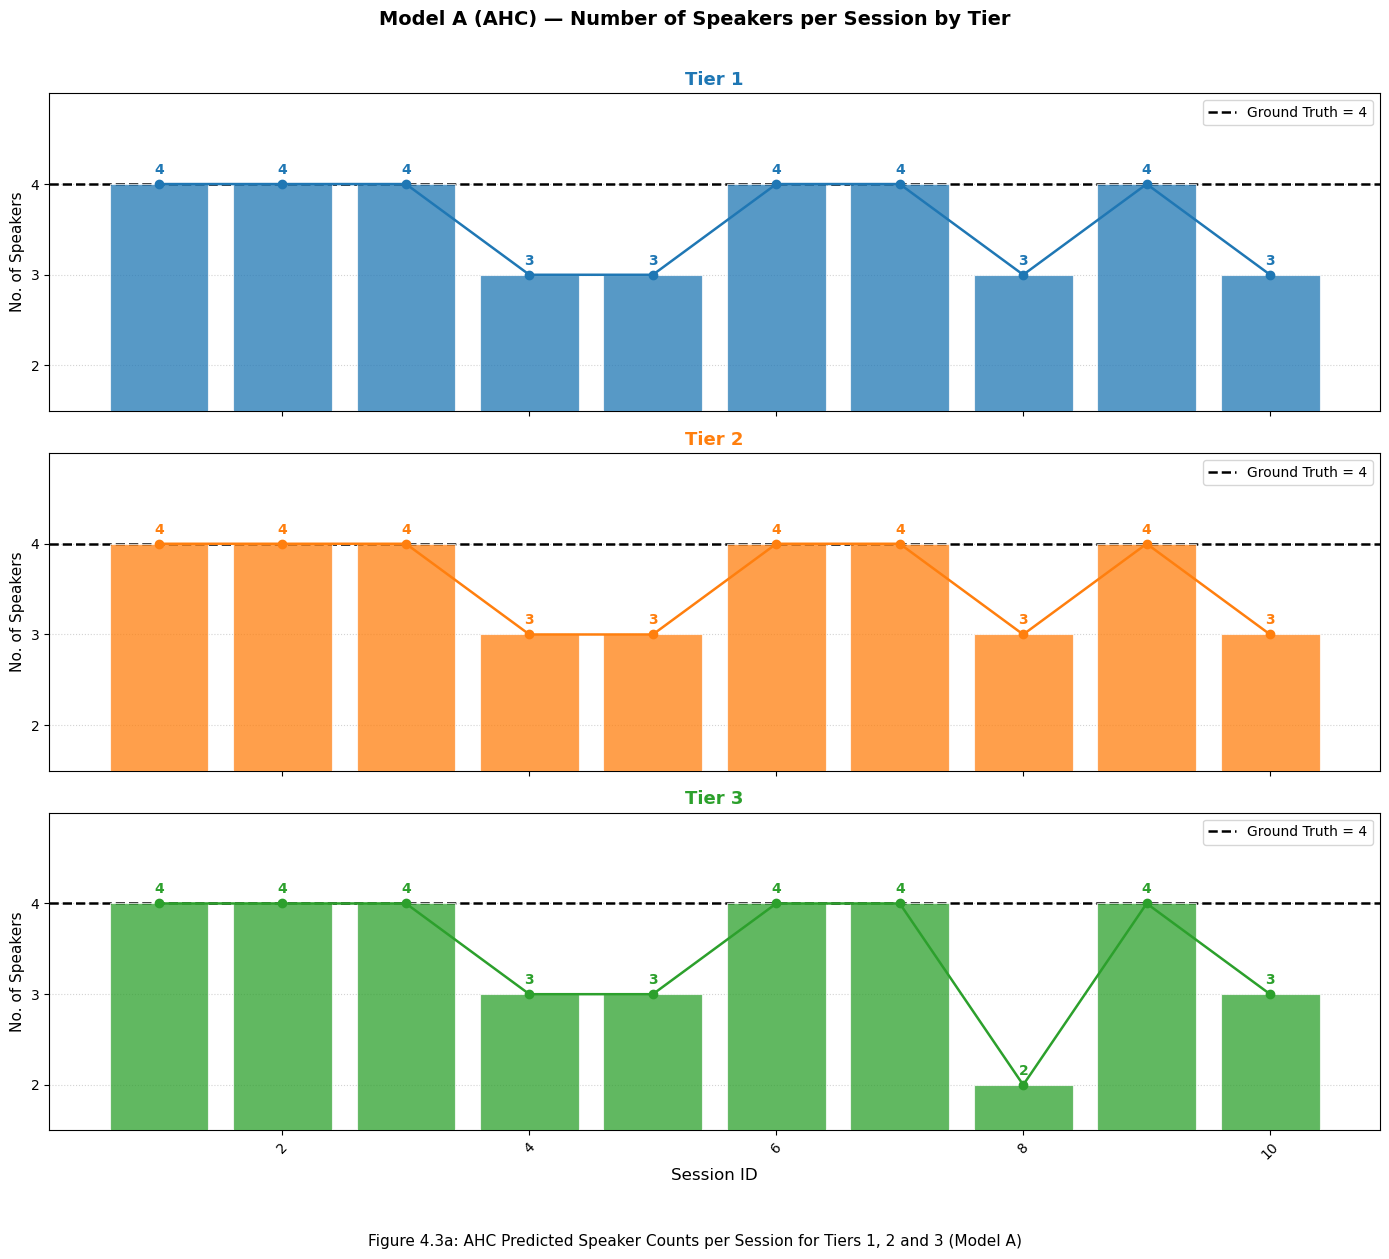

Plot saved as Model_A_Speaker_Count_Per_Session_By_Tier.png


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load & sort ───────────────────────────────────────────────────────────────
df = pd.read_csv(
    "/home/unbukenny/SHARC/Objective4_ESHARC_Outputs_V5/"
    "Silhoutte_speaker_t1_t2_t3combined_session_results.csv"
)
df = df.sort_values(["Tier", "Session_ID"]).reset_index(drop=True)

tier_order = sorted(df["Tier"].unique())          # e.g. ['Tier1', 'Tier2', 'Tier3']
palette    = dict(zip(tier_order, sns.color_palette("tab10", len(tier_order))))

# ── One subplot per tier, stacked vertically ──────────────────────────────────
fig, axes = plt.subplots(
    nrows=len(tier_order),
    ncols=1,
    figsize=(14, 4 * len(tier_order)),
    sharex=True,          # all panels share the same session x-axis
)

# Global y-range so tiers are directly comparable
spk_min = int(df["Num_Speakers"].min())
spk_max = int(df["Num_Speakers"].max())

for ax, tier in zip(axes, tier_order):
    grp = df[df["Tier"] == tier].copy()
    color = palette[tier]

    # Bar chart — one bar per session
    bars = ax.bar(
        grp["Session_ID"],
        grp["Num_Speakers"],
        color=color,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
    )

    # Overlay line + markers so trend is visible
    ax.plot(
        grp["Session_ID"],
        grp["Num_Speakers"],
        color=color,
        marker="o",
        markersize=6,
        linewidth=1.8,
        zorder=4,
    )

    # Annotate exact speaker count above every bar
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.08,
            str(int(row["Num_Speakers"])),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color=color,
            zorder=5,
        )

    # Ground-truth reference line
    ax.axhline(
        4,
        color="black",
        linestyle="--",
        linewidth=1.8,
        label="Ground Truth = 4",
        zorder=2,
    )

    # Consistent integer y-axis across all panels
    ax.set_ylim(spk_min - 0.5, spk_max + 1)
    ax.set_yticks(range(spk_min, spk_max + 1))
    ax.yaxis.set_tick_params(labelsize=10)

    ax.set_ylabel("No. of Speakers", fontsize=11)
    ax.set_title(f"{tier}", fontsize=13, fontweight="bold", color=color, pad=6)
    ax.legend(fontsize=10, loc="upper right")
    ax.grid(axis="y", linestyle=":", alpha=0.55, zorder=1)
    ax.set_axisbelow(True)

# Shared x-axis label on the bottom panel only (sharex=True)
axes[-1].set_xlabel("Session ID", fontsize=12)
axes[-1].tick_params(axis="x", labelsize=10, rotation=45)

# ── Titles & caption ──────────────────────────────────────────────────────────
fig.suptitle(
    "Model A (AHC) — Number of Speakers per Session by Tier",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

fig.text(
    0.5, -0.02,
    "Figure 4.3a: AHC Predicted Speaker Counts per Session for Tiers 1, 2 and 3 (Model A)",
    ha="center",
    fontsize=11,
)

# ── Save & display ────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig(
    "Model_A_Speaker_Count_Per_Session_By_Tier.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close()

print("Plot saved as Model_A_Speaker_Count_Per_Session_By_Tier.png")

## Model C Grid Search Optimization Result plot.

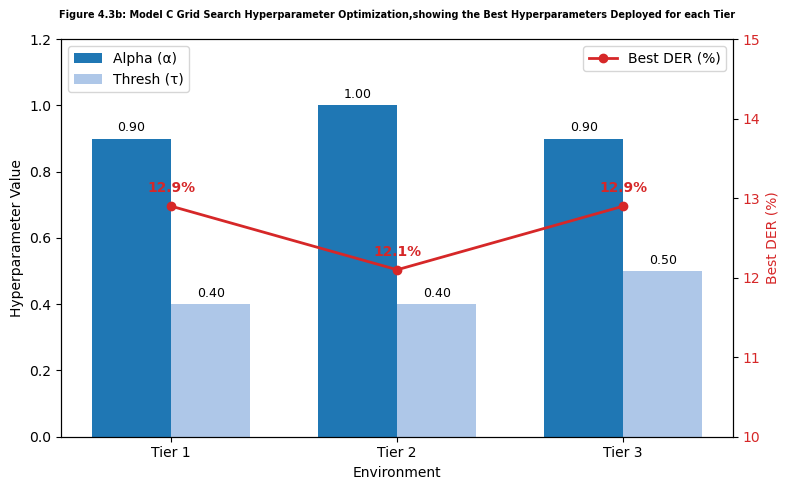

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Define performance and hyperparameter data per environment tier
tiers = ['Tier 1', 'Tier 2', 'Tier 3']
alphas = [0.90, 1.00, 0.90]       # Optimal alpha (α) values
thresholds = [0.40, 0.40, 0.50]   # Optimal threshold (τ) values
der = [12.9, 12.1, 12.9]          # Diarization Error Rate (%) values

# Initialize the plot figure and the primary axes (ax1)
fig, ax1 = plt.subplots(figsize=(8, 5))

# Configure primary x and y axis labels
ax1.set_xlabel('Environment')
ax1.set_ylabel('Hyperparameter Value', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Set up X-axis positions for the grouped bar charts
bar_width = 0.35
index = np.arange(len(tiers))
ax1.set_xticks(index)
ax1.set_xticklabels(tiers)
ax1.set_ylim(0, 1.2)

# Plot hyperparameters as side-by-side grouped bars
rects1 = ax1.bar(index - bar_width/2, alphas, bar_width, label='Alpha (α)', color='#1f77b4')
rects2 = ax1.bar(index + bar_width/2, thresholds, bar_width, label='Thresh (τ)', color='#aec7e8')

# Create a secondary Y-axis sharing the same X-axis for the DER metric
ax2 = ax1.twinx()  
ax2.set_ylabel('Best DER (%)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(10, 15)

# Plot DER data as a line graph on the secondary axis
line = ax2.plot(index, der, color='tab:red', marker='o', linewidth=2, label='Best DER (%)')

# Add chart title and independent legends for both axes
plt.title('Figure 4.3b: Model C Grid Search Hyperparameter Optimization,showing the Best Hyperparameters Deployed for each Tier', fontsize=7, fontweight='bold', pad=15)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Annotate value labels on top of the Alpha (α) bars
for rect in rects1:
    height = rect.get_height()
    ax1.annotate(f'{height:.2f}',
                 xy=(rect.get_x() + rect.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9)

# Annotate value labels on top of the Threshold (τ) bars
for rect in rects2:
    height = rect.get_height()
    ax1.annotate(f'{height:.2f}',
                 xy=(rect.get_x() + rect.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9)

# Annotate value labels above the DER line data points
for i, txt in enumerate(der):
    ax2.annotate(f'{txt}%', 
                 (index[i], der[i]), 
                 textcoords="offset points", 
                 xytext=(0, 10),  # 10 points vertical offset
                 ha='center', 
                 color='tab:red', 
                 weight='bold')

# Optimize layout geometry and export the figure to a high-resolution PNG
plt.tight_layout()

plt.savefig('Model_C_grid_search_optimization.png', dpi=300)

plt.show()   # Display the figure 

plt.close()  # Close the figure window to free memory

## ARCHITECTURE OF THE MODELS A TO D.

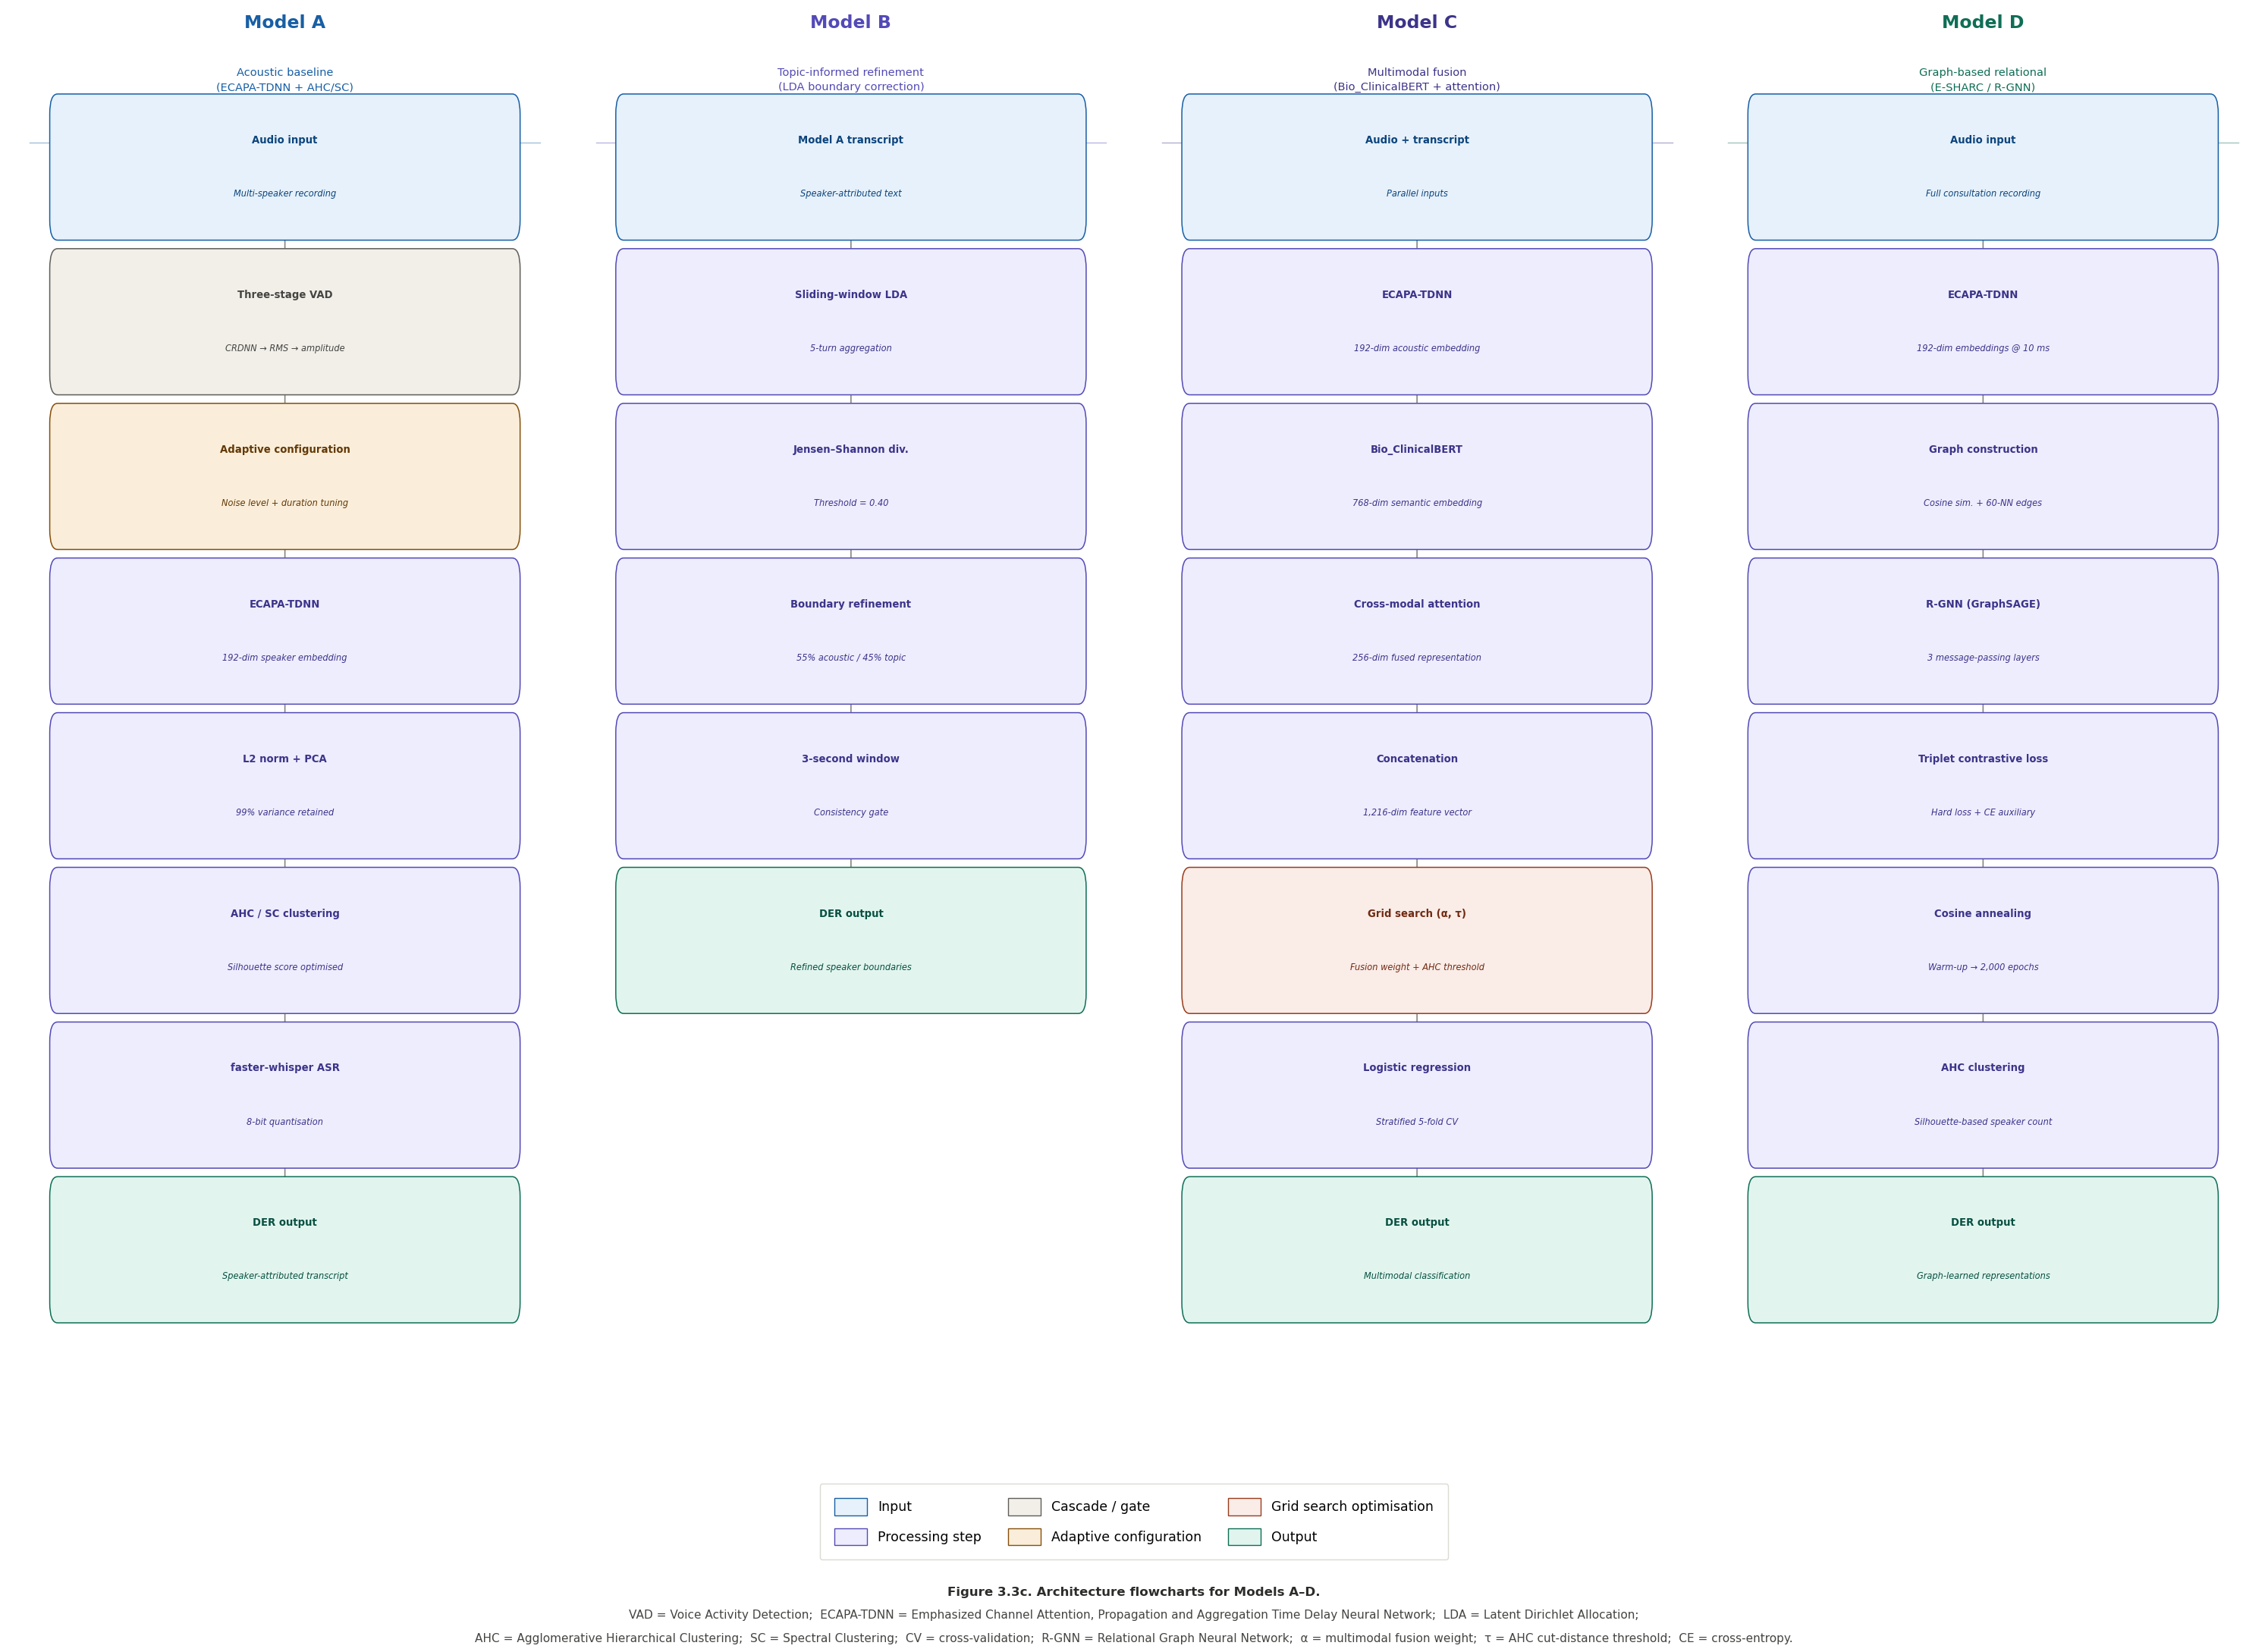

Done.


In [2]:
import matplotlib                                             # import matplotlib library for plotting
import matplotlib.patches as mpatches                         # import patches module for creating legend handles
import matplotlib.pyplot as plt                               # import pyplot for figure and axes creation
from matplotlib.patches import FancyBboxPatch                 # import FancyBboxPatch for drawing rounded rectangles
from pathlib import Path                                      # import Path to handle file paths in an OS-independent way
import os                                                     # import os module for filesystem operations

BASE_PATH = Path.cwd()                                        # get current working directory as a Path object
output_dir = BASE_PATH / "Objective4_ESHARC_Outputs_V5"       # define output directory path
if not os.path.exists(output_dir):                            # check whether the output directory exists
    os.makedirs(output_dir)                                   # create the output directory if it does not exist

fig, axes = plt.subplots(1, 4, figsize=(30, 22))              # create a figure with 1 row and 4 columns of subplots
fig.patch.set_facecolor("white")                              # set the figure background colour to white

COLORS = {                                                    # dictionary mapping logical block categories to hex colours
    "input":           "#E6F1FB",                             # soft light blue for input blocks
    "process":         "#EEEDFE",                             # light violet for processing steps
    "output":          "#E1F5EE",                             # light mint green for output blocks
    "shared":          "#F1EFE8",                             # light warm grey for shared/cascade blocks
    "adaptive":        "#FAEEDA",                             # light beige for adaptive configuration blocks
    "gridsearch":      "#FAECE7",                             # light peach for grid search blocks
    "border_input":    "#185FA5",                             # border colour for input blocks
    "border_process":  "#534AB7",                             # border colour for processing blocks
    "border_output":   "#0F6E56",                             # border colour for output blocks
    "border_shared":   "#5F5E5A",                             # border colour for shared blocks
    "border_adaptive": "#854F0B",                             # border colour for adaptive blocks
    "border_gs":       "#993C1D",                             # border colour for grid search blocks
    "text_input":      "#0C447C",                             # text colour for input blocks
    "text_process":    "#3C3489",                             # text colour for processing blocks
    "text_output":     "#085041",                             # text colour for output blocks
    "text_shared":     "#444441",                             # text colour for shared blocks
    "text_adaptive":   "#633806",                             # text colour for adaptive blocks
    "text_gs":         "#712B13",                             # text colour for grid search blocks
    "arrow":           "#888780",                             # colour for connecting arrows between boxes
}

BOX_W   = 0.82                                                # fixed width of each flowchart box in axes coordinates
BOX_H   = 0.075                                               # fixed height of each flowchart box
X_LEFT  = 0.09                                                # left x-coordinate where boxes start
ARROW_X = X_LEFT + BOX_W / 2                                  # horizontal centre of boxes, used for arrow placement
GAP     = 0.034                                               # vertical gap between boxes
Y_START = 0.850                                               # y-coordinate of the topmost box


def draw_box(ax, x, y, w, h, label, sublabel=None,            # draw a rounded box with main label and optional sublabel
             facecolor="#EEEDFE", edgecolor="#534AB7", textcolor="#3C3489"):
    box = FancyBboxPatch((x, y), w, h,                        # create a FancyBboxPatch with rounded corners
                         boxstyle="round,pad=0.014",
                         facecolor=facecolor, edgecolor=edgecolor,
                         linewidth=1.1, zorder=3)
    ax.add_patch(box)                                         # add the box patch to the current axes
    cy = y + h / 2                                            # vertical centre of the box
    if sublabel:                                              # if a sublabel string is provided
        ax.text(x + w/2, cy + 0.019, label,                  # place main label slightly above centre, bold
                ha="center", va="center", fontsize=9.5,
                fontweight="bold", color=textcolor, zorder=4)
        ax.text(x + w/2, cy - 0.019, sublabel,               # place sublabel slightly below centre, italic
                ha="center", va="center", fontsize=8.2,
                color=textcolor, style="italic", zorder=4)
    else:                                                     # if no sublabel is provided
        ax.text(x + w/2, cy, label,                           # place only the main label centred vertically
                ha="center", va="center", fontsize=9.5,
                fontweight="bold", color=textcolor, zorder=4)


def draw_arrow(ax, x, y_top, y_bot):                          # draw a downward-pointing arrow between two vertical positions
    ax.annotate("", xy=(x, y_bot + 0.003), xytext=(x, y_top - 0.003),
                arrowprops=dict(arrowstyle="->", color=COLORS["arrow"],
                                lw=1.2, mutation_scale=12),
                zorder=2)


def draw_model(ax, model_letter, subtitle, steps, title_color):  # render one complete model flowchart column on the given axes
    ax.set_xlim(0, 1)                                         # set x-axis limits from 0 to 1
    ax.set_ylim(0, 1)                                         # set y-axis limits from 0 to 1
    ax.axis("off")                                            # turn off axes spines, ticks and labels

    ax.text(0.5, 0.995, f"Model {model_letter}",             # add model title at the very top of the column
            ha="center", va="top",
            fontsize=17, fontweight="bold", color=title_color,
            transform=ax.transAxes)

    ax.text(0.5, 0.958, subtitle,                            # add model subtitle below the title
            ha="center", va="top",
            fontsize=10.5, fontweight="normal", color=title_color,
            transform=ax.transAxes, linespacing=1.5)

    ax.axhline(y=0.905, xmin=0.04, xmax=0.96,                # draw a horizontal separator line below the header
               color=title_color, linewidth=1.0, alpha=0.4)

    positions = []                                             # list to store y-coordinates of all boxes for arrow drawing
    for i, step in enumerate(steps):                          # iterate through the list of step dictionaries
        y = Y_START - i * (BOX_H + GAP)                       # compute y-coordinate for the current box
        positions.append(y)                                   # store the y-coordinate
        draw_box(ax, X_LEFT, y, BOX_W, BOX_H,                 # draw the box for this step
                 step["label"], step.get("sub"),
                 facecolor=step.get("fc", COLORS["process"]),
                 edgecolor=step.get("ec", COLORS["border_process"]),
                 textcolor=step.get("tc", COLORS["text_process"]))

    for i in range(len(positions) - 1):                       # draw an arrow between each pair of consecutive boxes
        draw_arrow(ax, ARROW_X, positions[i], positions[i+1] + BOX_H)


# shortcut dictionaries that bundle fill, edge and text colours for each block type
IN  = dict(fc=COLORS["input"],      ec=COLORS["border_input"],    tc=COLORS["text_input"])   # colours for input blocks
PR  = dict(fc=COLORS["process"],    ec=COLORS["border_process"],  tc=COLORS["text_process"]) # colours for processing steps
SH  = dict(fc=COLORS["shared"],     ec=COLORS["border_shared"],   tc=COLORS["text_shared"])  # colours for shared/cascade steps
OUT = dict(fc=COLORS["output"],     ec=COLORS["border_output"],   tc=COLORS["text_output"])  # colours for output blocks
AD  = dict(fc=COLORS["adaptive"],   ec=COLORS["border_adaptive"], tc=COLORS["text_adaptive"])# colours for adaptive config blocks
GS  = dict(fc=COLORS["gridsearch"], ec=COLORS["border_gs"],       tc=COLORS["text_gs"])      # colours for grid search blocks

model_a_steps = [                                            # list of step dictionaries for Model A (acoustic baseline)
    {**IN,  "label": "Audio input",            "sub": "Multi-speaker recording"},                # input block: multi-speaker recording
    {**SH,  "label": "Three-stage VAD",        "sub": "CRDNN → RMS → amplitude"},               # shared VAD step
    {**AD,  "label": "Adaptive configuration", "sub": "Noise level + duration tuning"},         # adaptive parameter tuning
    {**PR,  "label": "ECAPA-TDNN",             "sub": "192-dim speaker embedding"},             # processing: ECAPA-TDNN embedding
    {**PR,  "label": "L2 norm + PCA",          "sub": "99% variance retained"},                 # processing: normalisation and PCA
    {**PR,  "label": "AHC / SC clustering",    "sub": "Silhouette score optimised"},            # processing: clustering
    {**PR,  "label": "faster-whisper ASR",     "sub": "8-bit quantisation"},                    # processing: speech recognition
    {**OUT, "label": "DER output",             "sub": "Speaker-attributed transcript"},         # output: DER transcript
]

model_b_steps = [                                            # list of step dictionaries for Model B (topic refinement)
    {**IN,  "label": "Model A transcript",     "sub": "Speaker-attributed text"},                # input block: transcript from Model A
    {**PR,  "label": "Sliding-window LDA",     "sub": "5-turn aggregation"},                    # processing: LDA topic modelling
    {**PR,  "label": "Jensen–Shannon div.",    "sub": "Threshold = 0.40"},                      # processing: divergence thresholding
    {**PR,  "label": "Boundary refinement",    "sub": "55% acoustic / 45% topic"},             # processing: acoustic-topic fusion
    {**PR,  "label": "3-second window",        "sub": "Consistency gate"},                      # processing: consistency gate
    {**OUT, "label": "DER output",             "sub": "Refined speaker boundaries"},            # output: refined DER boundaries
]

model_c_steps = [                                            # list of step dictionaries for Model C (multimodal fusion)
    {**IN,  "label": "Audio + transcript",     "sub": "Parallel inputs"},                        # input block: audio and transcript
    {**PR,  "label": "ECAPA-TDNN",             "sub": "192-dim acoustic embedding"},             # processing: acoustic embedding
    {**PR,  "label": "Bio_ClinicalBERT",       "sub": "768-dim semantic embedding"},            # processing: clinical BERT embedding
    {**PR,  "label": "Cross-modal attention",  "sub": "256-dim fused representation"},          # processing: cross-modal attention
    {**PR,  "label": "Concatenation",          "sub": "1,216-dim feature vector"},              # processing: feature concatenation
    {**GS,  "label": "Grid search (α, τ)",     "sub": "Fusion weight + AHC threshold"},         # grid search over hyperparameters
    {**PR,  "label": "Logistic regression",    "sub": "Stratified 5-fold CV"},                  # processing: logistic regression
    {**OUT, "label": "DER output",             "sub": "Multimodal classification"},             # output: multimodal DER classification
]

model_d_steps = [                                            # list of step dictionaries for Model D (graph-based relational)
    {**IN,  "label": "Audio input",              "sub": "Full consultation recording"},           # input block: full recording
    {**PR,  "label": "ECAPA-TDNN",               "sub": "192-dim embeddings @ 10 ms"},           # processing: ECAPA-TDNN at 10 ms
    {**PR,  "label": "Graph construction",        "sub": "Cosine sim. + 60-NN edges"},          # processing: build similarity graph
    {**PR,  "label": "R-GNN (GraphSAGE)",         "sub": "3 message-passing layers"},           # processing: relational GNN
    {**PR,  "label": "Triplet contrastive loss",  "sub": "Hard loss + CE auxiliary"},           # processing: contrastive loss
    {**PR,  "label": "Cosine annealing",          "sub": "Warm-up → 2,000 epochs"},             # processing: learning rate schedule
    {**PR,  "label": "AHC clustering",            "sub": "Silhouette-based speaker count"},      # processing: clustering
    {**OUT, "label": "DER output",                "sub": "Graph-learned representations"},       # output: DER output
]

MODEL_CONFIGS = [                                            # list of (model letter, subtitle, steps, title colour) tuples
    ("A", "Acoustic baseline\n(ECAPA-TDNN + AHC/SC)",            model_a_steps, "#185FA5"),
    ("B", "Topic-informed refinement\n(LDA boundary correction)", model_b_steps, "#534AB7"),
    ("C", "Multimodal fusion\n(Bio_ClinicalBERT + attention)",    model_c_steps, "#3C3489"),
    ("D", "Graph-based relational\n(E-SHARC / R-GNN)",            model_d_steps, "#0F6E56"),
]

for ax, (letter, subtitle, steps, tc) in zip(axes, MODEL_CONFIGS):  # iterate over each subplot and corresponding model config
    draw_model(ax, letter, subtitle, steps, title_color=tc)         # draw the flowchart for that model on its axes

legend_elements = [                                          # create a list of legend handles for the block colours
    mpatches.Patch(facecolor=COLORS["input"],      edgecolor=COLORS["border_input"],    label="Input"),              # input legend entry
    mpatches.Patch(facecolor=COLORS["process"],    edgecolor=COLORS["border_process"],  label="Processing step"),     # processing legend entry
    mpatches.Patch(facecolor=COLORS["shared"],     edgecolor=COLORS["border_shared"],   label="Cascade / gate"),      # shared/cascade legend entry
    mpatches.Patch(facecolor=COLORS["adaptive"],   edgecolor=COLORS["border_adaptive"], label="Adaptive configuration"), # adaptive legend entry
    mpatches.Patch(facecolor=COLORS["gridsearch"], edgecolor=COLORS["border_gs"],       label="Grid search optimisation"), # grid search legend entry
    mpatches.Patch(facecolor=COLORS["output"],     edgecolor=COLORS["border_output"],   label="Output"),              # output legend entry
]

fig.legend(                                                  # add a figure-level legend at the bottom centre
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=12.5,
    bbox_to_anchor=(0.5, 0.058),
    edgecolor="#D3D1C7",
    facecolor="white",
    handlelength=2.5,
    handleheight=1.6,
    borderpad=1.1,
    labelspacing=1.0,
    columnspacing=2.0,
)

fig.text(0.5, 0.046, "Figure 3.3c. Architecture flowcharts for Models A–D.",   # add main figure caption
         ha="center", va="top", fontsize=12, fontweight="bold", color="#2C2C2A")

fig.text(0.5, 0.032,                                            # add first line of acronym explanations
         "VAD = Voice Activity Detection;  ECAPA-TDNN = Emphasized Channel Attention, "
         "Propagation and Aggregation Time Delay Neural Network;  "
         "LDA = Latent Dirichlet Allocation;",
         ha="center", va="top", fontsize=11, color="#444441")

fig.text(0.5, 0.018,                                            # add second line of acronym explanations
         "AHC = Agglomerative Hierarchical Clustering;  SC = Spectral Clustering;  "
         "CV = cross-validation;  R-GNN = Relational Graph Neural Network;  "
         "α = multimodal fusion weight;  τ = AHC cut-distance threshold;  CE = cross-entropy.",
         ha="center", va="top", fontsize=11, color="#444441")

plt.tight_layout(rect=[0, 0.135, 1, 0.999])                    # adjust layout, leaving space for legends and captions at bottom
plt.savefig(f"{output_dir}/model_architectures_v5.png", dpi=300, bbox_inches="tight", facecolor="white")  # save PNG version
plt.savefig(f"{output_dir}/model_architectures_v5.pdf", bbox_inches="tight", facecolor="white")            # save PDF version
plt.show()  # Display the Architecture
print("Done.")                                                 # print confirmation to console

# The End of This Project.